# Load packages

Read in all necessary packages:

In [5]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scanpy as sc
import numpy as np
import decoupler as dc


In [2]:
# Import DESeq2
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

In [3]:
import decoupler as dc

In [4]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

## load adata file and define groups for differential expression

In [6]:
adata = sc.read_h5ad('../../../tchic_local/fig6_build/legacy/data/20230704_adata_all.h5ad')
adata

AnnData object with n_obs × n_vars = 38117 × 27384
    obs: 'batch', 'day', 'replicates', 'mark', 'day_rep', 'dataset', 'hour', 'celltype', 'celltype_general', 'lineage', 'lin_day', 'percent_mito', 'n_counts', 'n_counts_proteincoding', 'n_genes', 'S_score', 'G2M_score', 'phase', 'enrichment', 'coverage', 'QC', 'pseudotime', 'pseudotime2'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'gene', 'gene_biotype', 'gene_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'QC_colors', 'batch_colors', 'celltype_colors', 'celltype_general_colors', 'dataset_colors', 'day_colors', 'hour_colors', 'hvg', 'leiden', 'leiden_colors', 'lin_day_colors', 'lineage_colors', 'log1p', 'mark_colors', 'neighbors', 'old_celltype_colors', 'old_leiden_general_colors', 'old_leiden_merge_colors', 'pca', 'phase_colors', 'predicted_final_colors', 'predicted_id_E75_colors', 'predicted_id_E85_colors', 'replicates_colors', 'umap', 'umap_density_mark_par

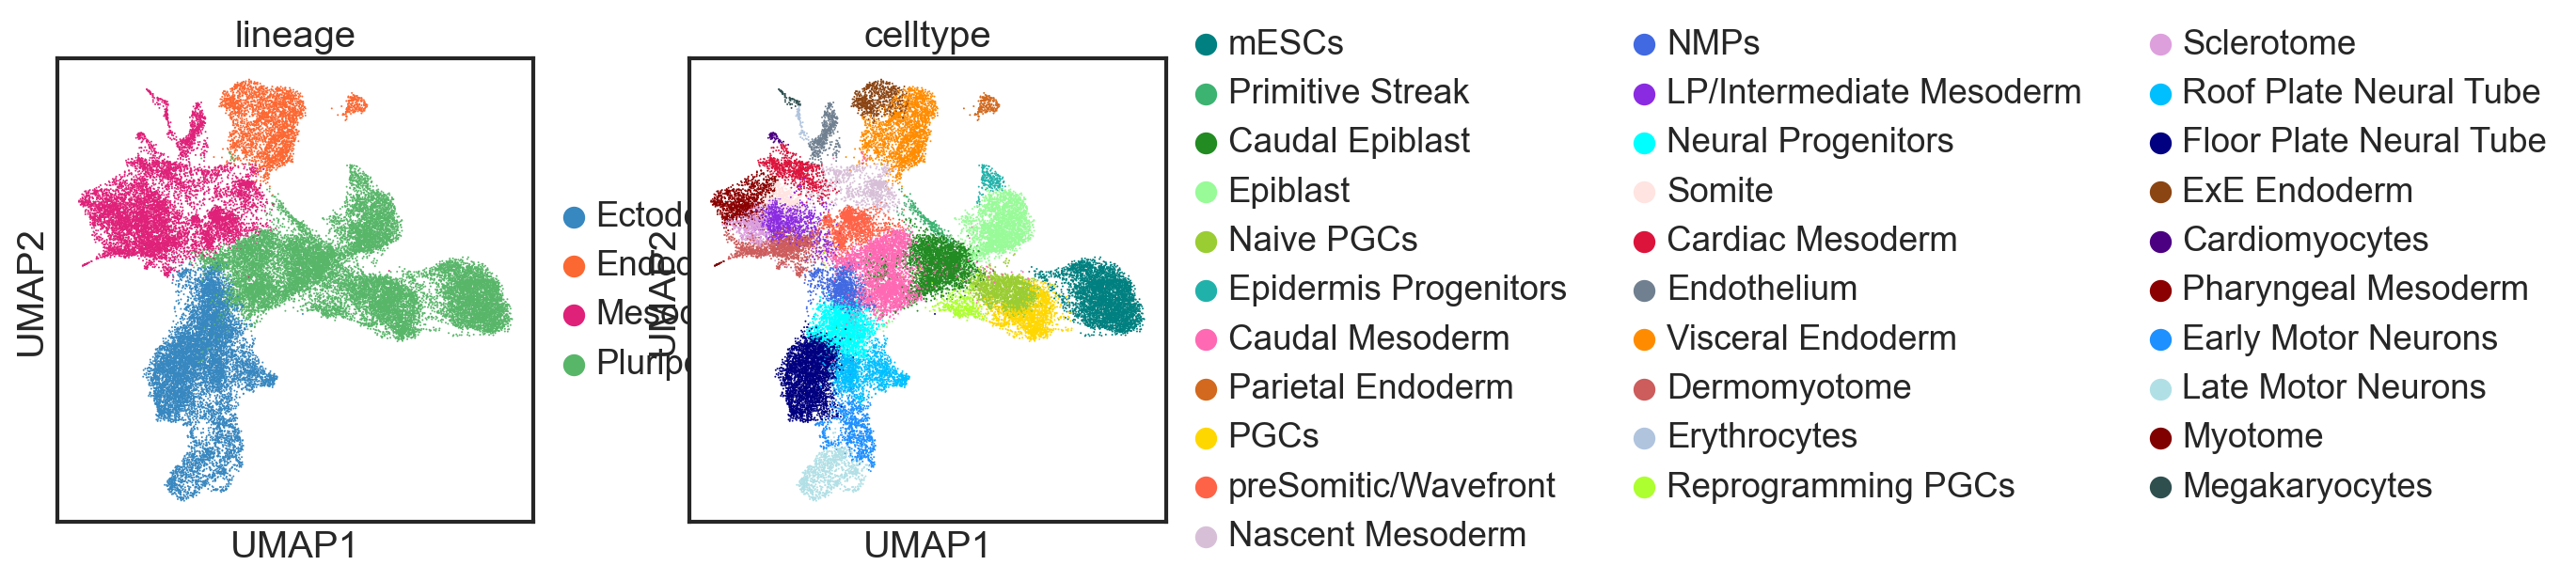

In [7]:
sc.pl.umap(adata, color = ['lineage', 'celltype'])

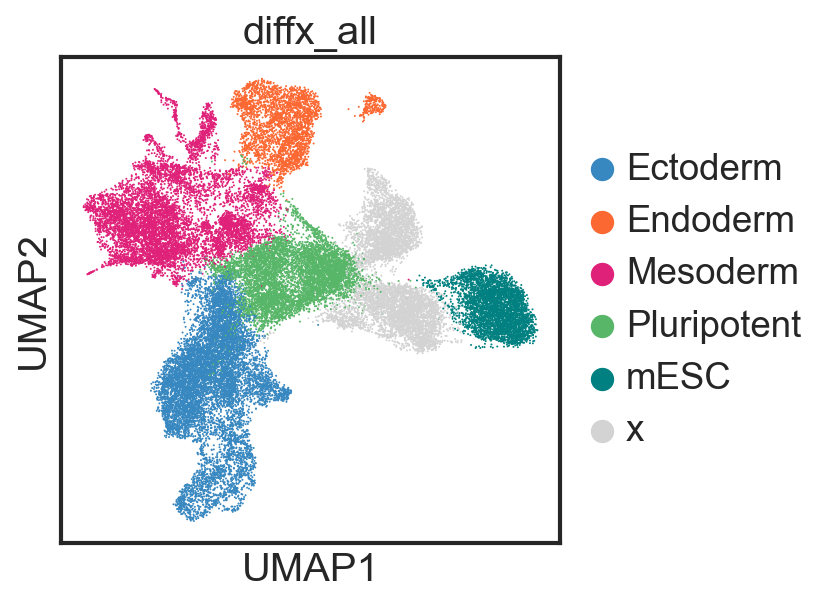

In [8]:
dict_ct = {'Mesoderm':'Mesoderm',
 'Ectoderm':'Ectoderm',
 'Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent'}

adata.obs['diffx_all'] = (
    adata.obs["lineage"]
    .map(lambda x: dict_ct.get(x, x))
    .astype("category")
)

adata.obs['diffx_all'] = adata.obs['diffx_all'].astype(str)
adata.obs.loc[list(adata[adata.obs['celltype'] == 'mESCs'].obs.index), 'diffx_all'] = 'mESC'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'PGCs'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epidermis Progenitors'].obs.index), 'diffx_all'] = 'x'
adata.obs.loc[list(adata[adata.obs['celltype_general'] == 'Epiblast'].obs.index), 'diffx_all'] = 'x'

cols = ['#3787c0', '#fc6832','#df2179', '#58b669','teal','lightgrey']
sc.pl.umap(adata, color = 'diffx_all', palette = cols )

## all comparisons

In [9]:
dict_ct = {'Mesoderm':'x','Ectoderm':'x','Endoderm':'x',
           'Pluripotent':'Pluripotent','x':'x','mESC':'mESC'}
adata.obs['diffx_ESC_p'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))


dict_ct = {'Mesoderm':'diff','Ectoderm':'diff','Endoderm':'diff',
           'Pluripotent':'Pluripotent','x':'x','mESC':'x'}
adata.obs['diffx_p_diff'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))

dict_ct = {'Mesoderm':'Mesoderm','Ectoderm':'Ectoderm','Endoderm':'Endoderm',
           'Pluripotent':'Pluripotent','x':'x','mESC':'x'}
adata.obs['diffx_diff_p'] = (adata.obs["diffx_all"].map(lambda x: dict_ct.get(x, x)).astype("category"))

adata.uns['diffx_ESC_p_colors'] = ['#58b669','teal','lightgrey']
adata.uns['diffx_p_diff_colors'] = ['#58b669','#df2179','lightgrey']
adata.uns['diffx_diff_p_colors'] = ['#3787c0', '#fc6832','#df2179', '#58b669','lightgrey']

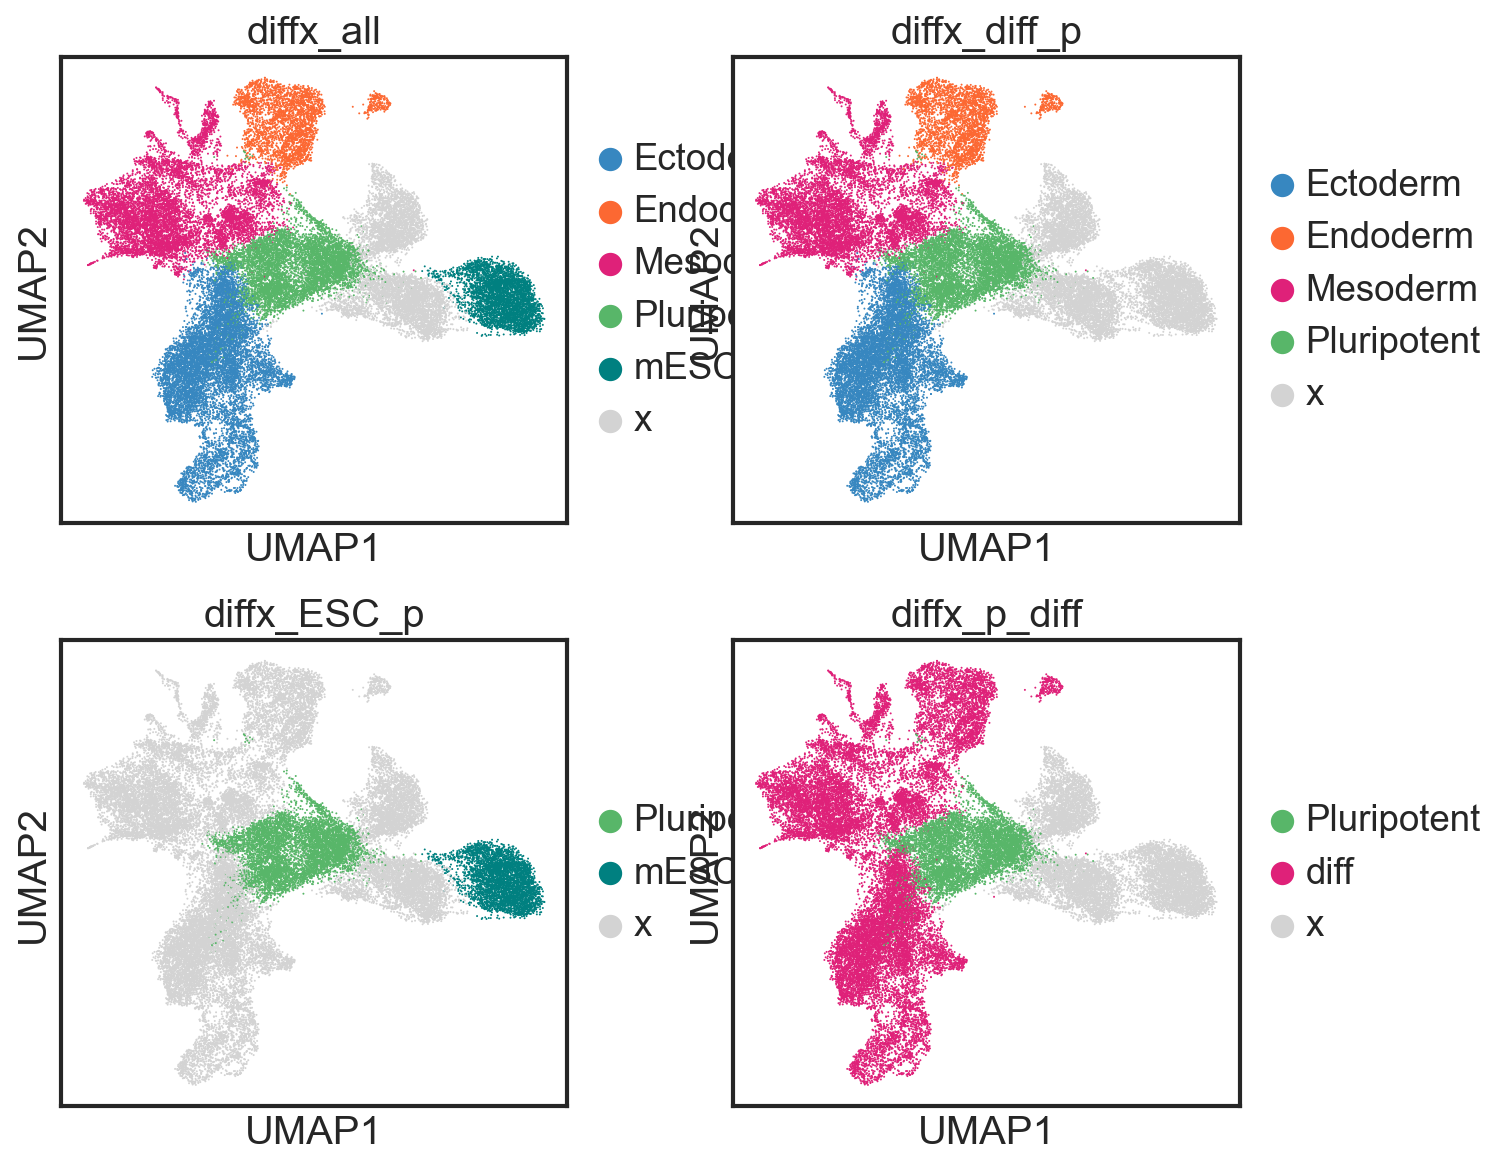

In [10]:
sc.pl.umap(adata, color = ['diffx_all','diffx_diff_p','diffx_ESC_p','diffx_p_diff'], ncols = 2)

In [11]:
sc.settings.verbosity = 2

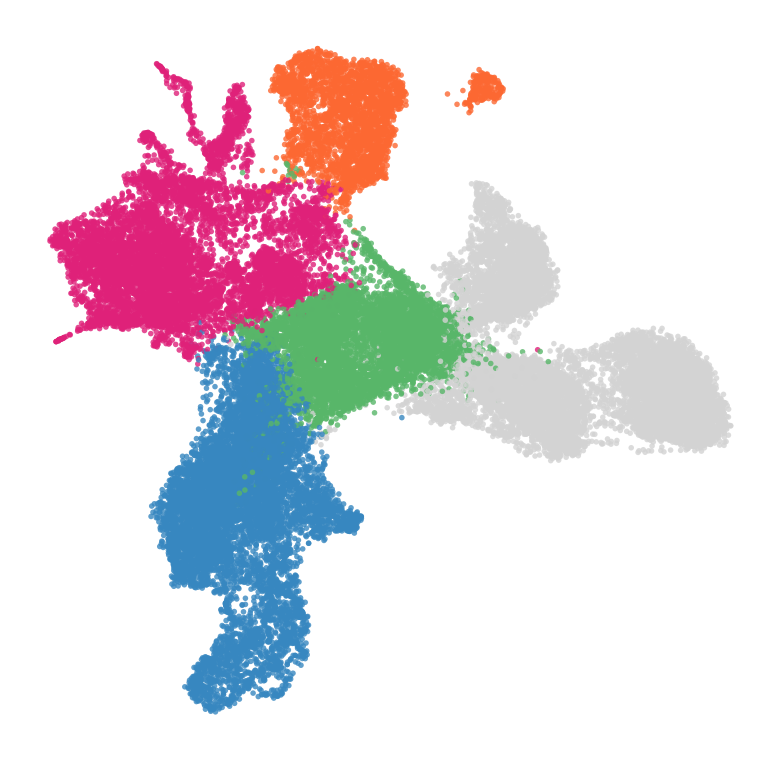

In [12]:
fig, ax = plt.subplots(figsize = (6,6))
sc.pl.umap(adata, color = ['diffx_diff_p'], ncols = 2, frameon = False, title = '', legend_loc = None,ax=ax, size = 25, alpha = 0.8,
           save = '20250414_UMAP_lins.png')

## load the tables with differentially expressed genes

In [13]:
PvsDIFF = pd.read_csv('dfs/20250310_diff_genes_PvsDIFF.csv')
ESCvsP = pd.read_csv('dfs/20250310_diff_genes_ESCvsP.csv')
PvsECT = pd.read_csv('dfs/20250310_diff_genes_PvsECT.csv')
PvsEND = pd.read_csv('dfs/20250310_diff_genes_PvsEND.csv')
PvsMES = pd.read_csv('dfs/20250310_diff_genes_PvsMES.csv')

In [14]:
def up_down_genes(results_df):
    up = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] > 2)].sort_values(by = 'log2FoldChange',ascending=True)
    down = results_df[(results_df['padj'] < 0.05) & (results_df['log2FoldChange'] < -2)].sort_values(by = 'log2FoldChange',ascending=True)
    return up,down


In [15]:
PvsDIFF_up, PvsDIFF_down = up_down_genes(PvsDIFF)
ESCvsP_up, ESCvsP_down = up_down_genes(ESCvsP)
PvsECT_up, PvsECT_down = up_down_genes(PvsECT)
PvsEND_up, PvsEND_down = up_down_genes(PvsEND)
PvsMES_up, PvsMES_down = up_down_genes(PvsMES)

In [16]:
print('up, \t \t \t down')
print( PvsDIFF_up.shape[0]/PvsDIFF.shape[0]*100,
      PvsDIFF_down.shape[0]/PvsDIFF.shape[0]*100)

print( ESCvsP_up.shape[0]/ESCvsP.shape[0]*100,
      ESCvsP_down.shape[0]/ESCvsP.shape[0]*100)

print( PvsECT_up.shape[0]/PvsECT.shape[0]*100,
      PvsECT_down.shape[0]/PvsECT.shape[0]*100)

print( PvsEND_up.shape[0]/PvsEND.shape[0]*100,
      PvsEND_down.shape[0]/PvsEND.shape[0]*100)

print( PvsMES_up.shape[0]/PvsMES.shape[0]*100,
      PvsMES_down.shape[0]/PvsMES.shape[0]*100)

up, 	 	 	 down
4.225513836261339 1.2630612010563786
5.600382932166302 5.648249452954048
3.6784126779617345 2.6541261354119694
5.713497101849296 2.773944245100745
4.539845424433331 2.2212119244008575


# Plotting gene sets

## volcano plots

In [17]:
PvsECT_down.head(2)

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,p_log10
12858,Sprr2a3,40.732297,-6.163475,0.532630,-11.571776,5.728453e-31,2.249501e-30,29.647914
8668,Mixl1,528.303381,-5.978765,0.156243,-38.265871,0.000000e+00,0.000000e+00,inf


In [18]:
color_pal = dict(zip(adata.obs['diffx_all'].cat.categories,adata.uns[str('diffx_all') + '_colors']))
#cols = [color_pal[list(pdata.obs[groups].unique())[0]]] + [color_pal[list(pdata.obs[groups].unique())[1]]]
color_pal

{'Ectoderm': '#3787c0',
 'Endoderm': '#fc6832',
 'Mesoderm': '#df2179',
 'Pluripotent': '#58b669',
 'mESC': '#008080',
 'x': '#d3d3d3'}

In [19]:
def makeVolcano(df, df_up, df_down, lfc = 'log2FoldChange', cols = ['red','blue'], save = None):
    fig,ax = plt.subplots(figsize = (4,4))
    
    sns.scatterplot(data = df,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',alpha = 0.4,
                   c = 'grey')
    
    sns.scatterplot(data = df_up,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',
                   c = cols[0] )
    
    sns.scatterplot(data = df_down,
                   x = lfc,s=12,edgecolor = None,
                   y = 'p_log10',
                   c = cols[1] )
    ax.legend([],frameon=False)
    ax.set_ylabel('log10 [p-value]')
    ax.set_xlabel('log2 FC')
    ax.set_xlim([-11,11])
    ax.set_ylim([-15,340])
    print(df_down.shape[0],df_up.shape[0])
    if save != None:
        plt.savefig(save, bbox_inches='tight', dpi = 300)
    plt.show()

826 819


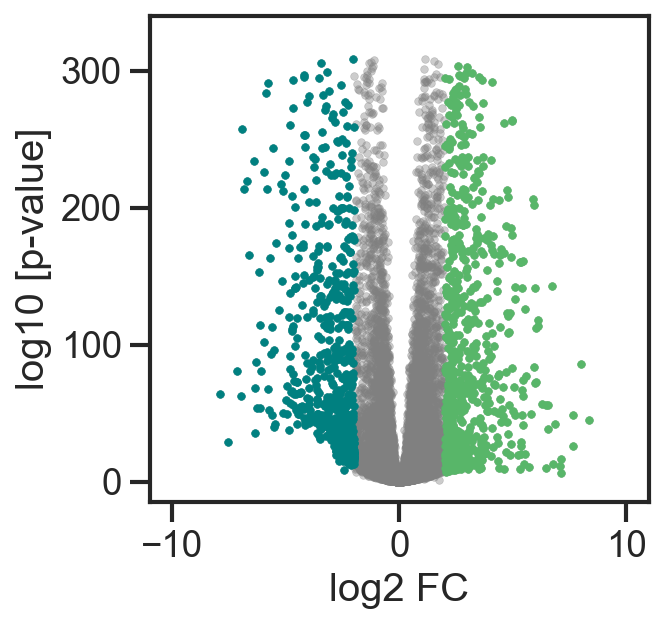

In [20]:
makeVolcano(ESCvsP, ESCvsP_up,ESCvsP_down, cols = [color_pal['Pluripotent'],color_pal['mESC']] )

220 736


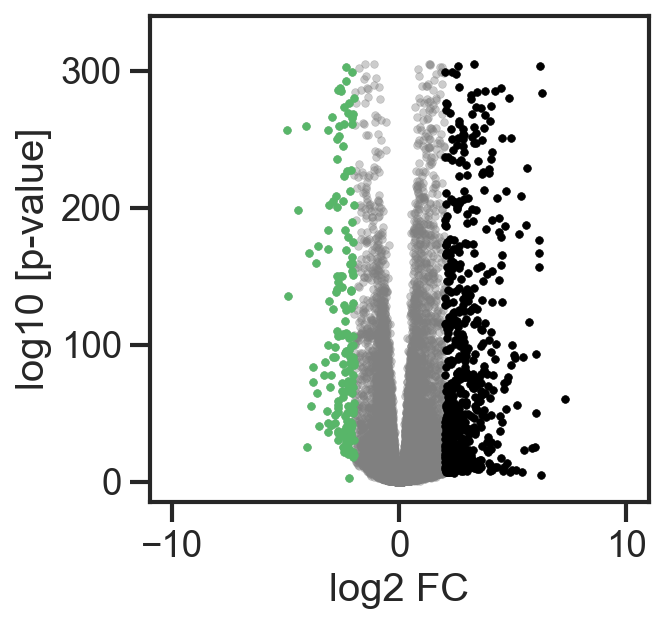

In [21]:
makeVolcano(PvsDIFF, PvsDIFF_up,PvsDIFF_down, cols = ['black',color_pal['Pluripotent']] )

412 571


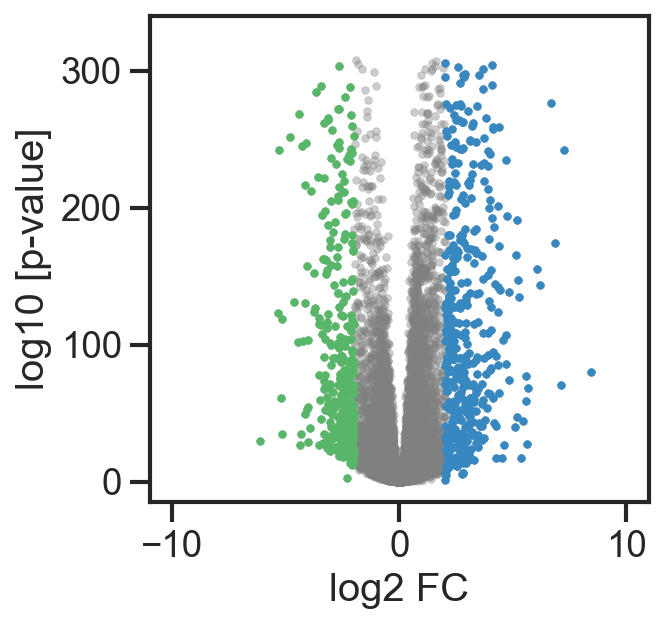

In [22]:
makeVolcano(PvsECT, PvsECT_up,PvsECT_down, cols = [color_pal['Ectoderm'],color_pal['Pluripotent']] )

342 699


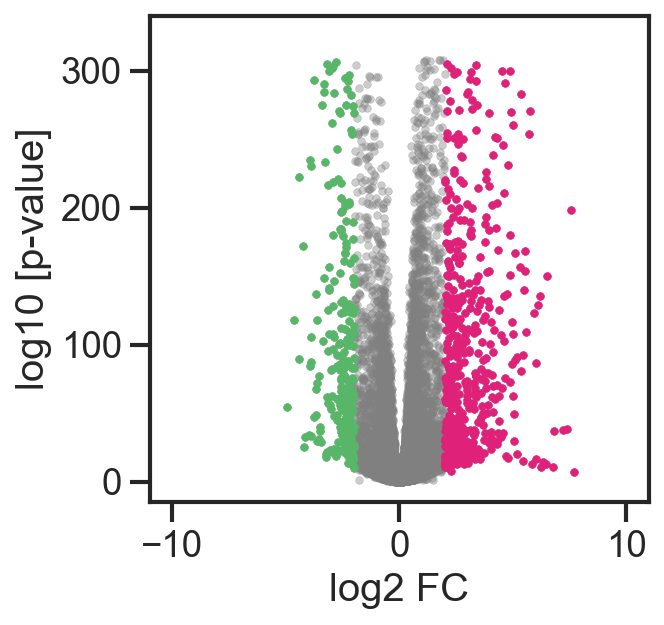

In [23]:
makeVolcano(PvsMES, PvsMES_up,PvsMES_down, cols = [color_pal['Mesoderm'],color_pal['Pluripotent']] )

402 828


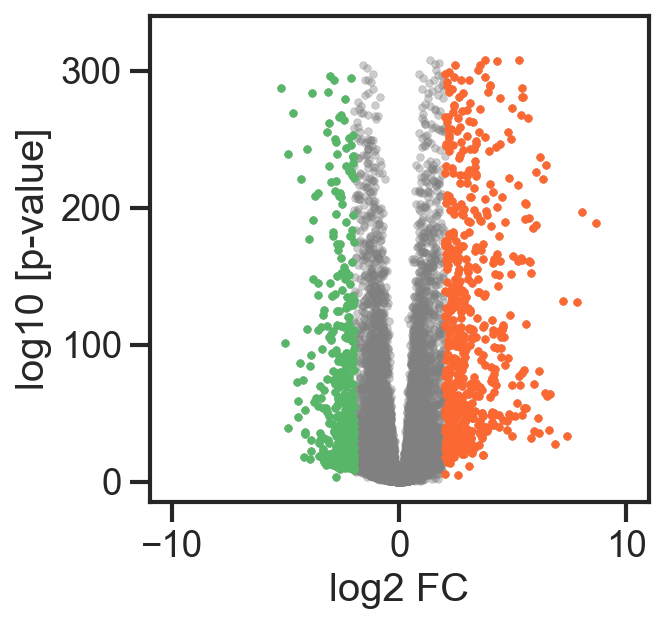

In [24]:
makeVolcano(PvsEND, PvsEND_up,PvsEND_down, cols = [color_pal['Endoderm'],color_pal['Pluripotent']] )

## GO term analysis

In [25]:
def plotGO(genelist, reflist, n = 10, save = None, source = 'GO:BP', col = 'grey'):
    plotcl = sc.queries.enrich({'cluster':genelist,
                   'all':reflist}, org="mmusculus")
    cluster = 'cluster'
    plot1 = plotcl[plotcl['query'] == cluster][plotcl[plotcl['query'] == cluster]['source'] == source].sort_values(by='p_value')[['name','p_value']][0:n]
    plot1['-log (p-value)'] = np.log10(plot1['p_value'])*-1
    sns.set_style('ticks')
    sns.set_context('talk')
    fig,ax = plt.subplots(figsize = (6,3))
    ax = sns.barplot(y=plot1['name'],x=plot1['-log (p-value)'], ax=ax,color = col)
    ax.set_ylabel('')
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    #sns.despine()
    plt.show()

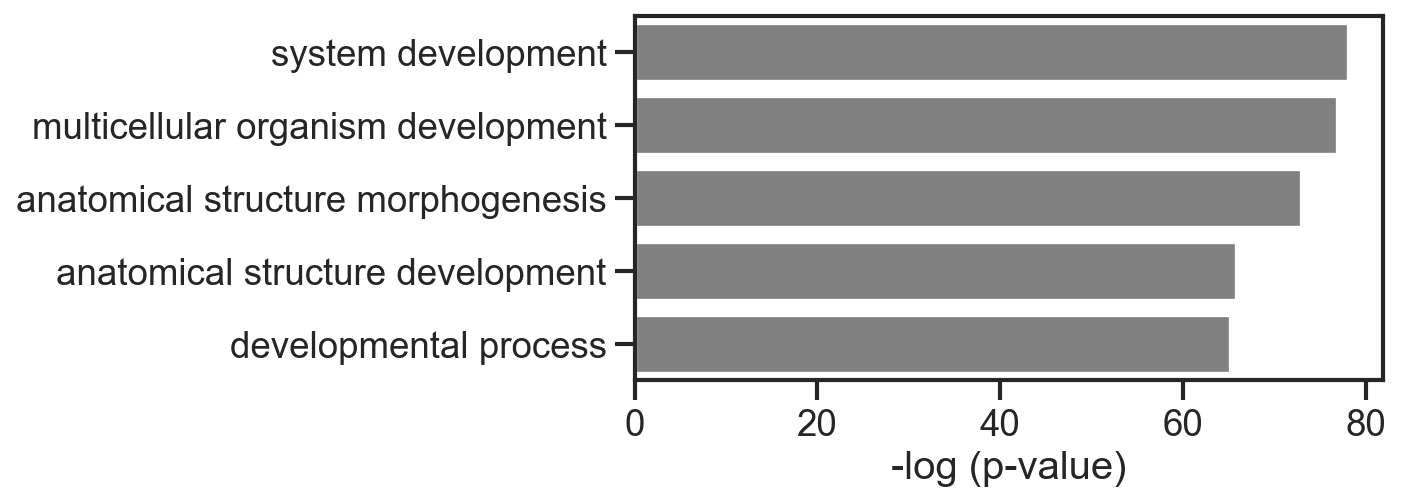

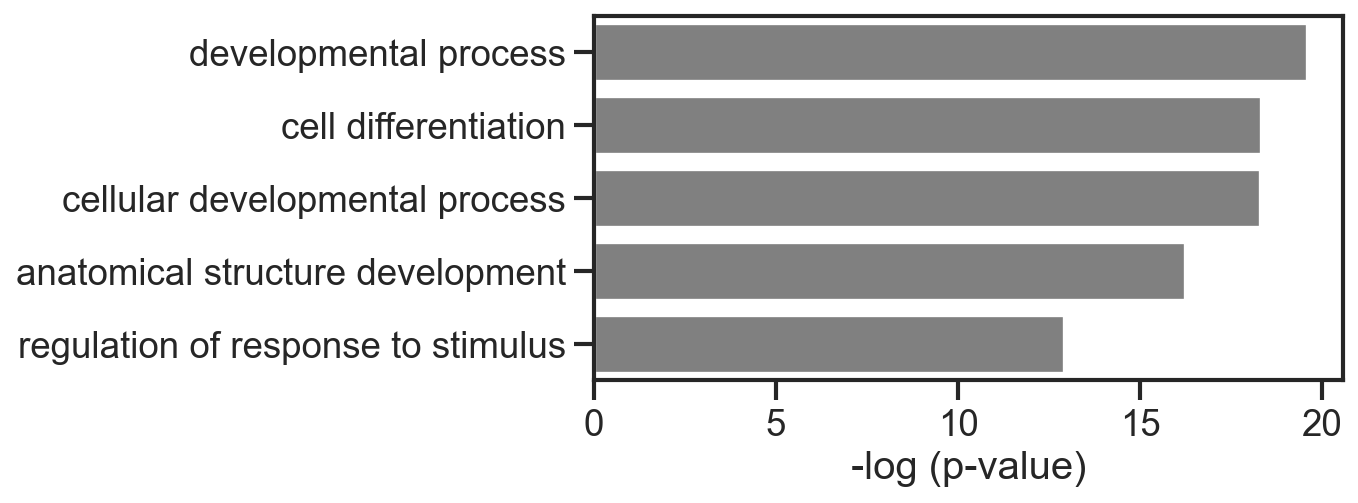

In [26]:
allgenes = list(ESCvsP['Gene'].unique())
plotGO(list(ESCvsP_up['Gene']),allgenes, n = 5)
plotGO(list(ESCvsP_down['Gene']),allgenes, n = 5)

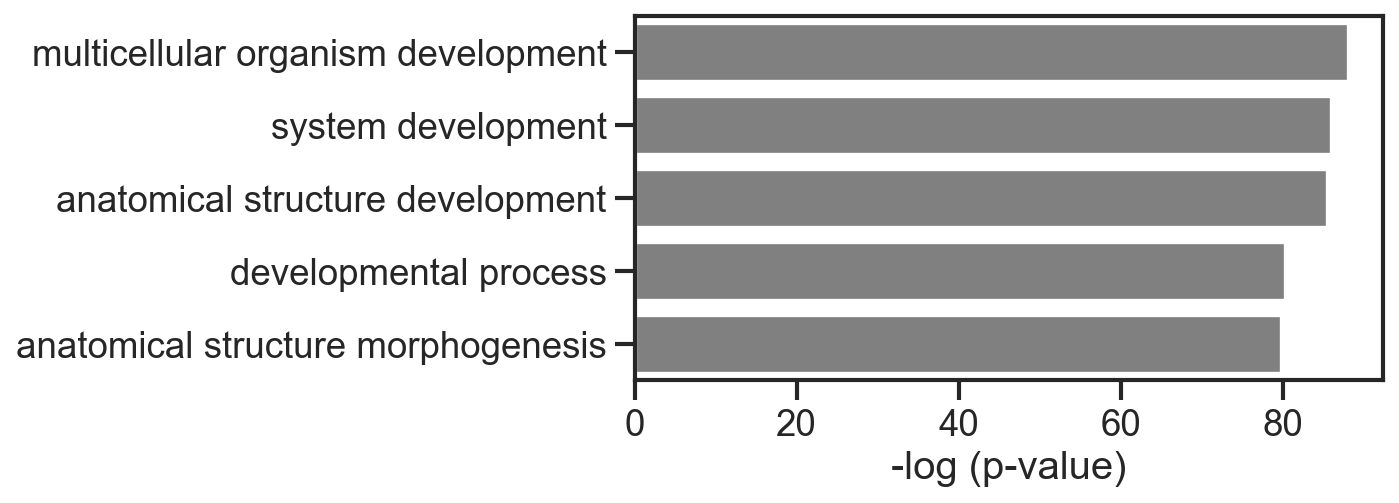

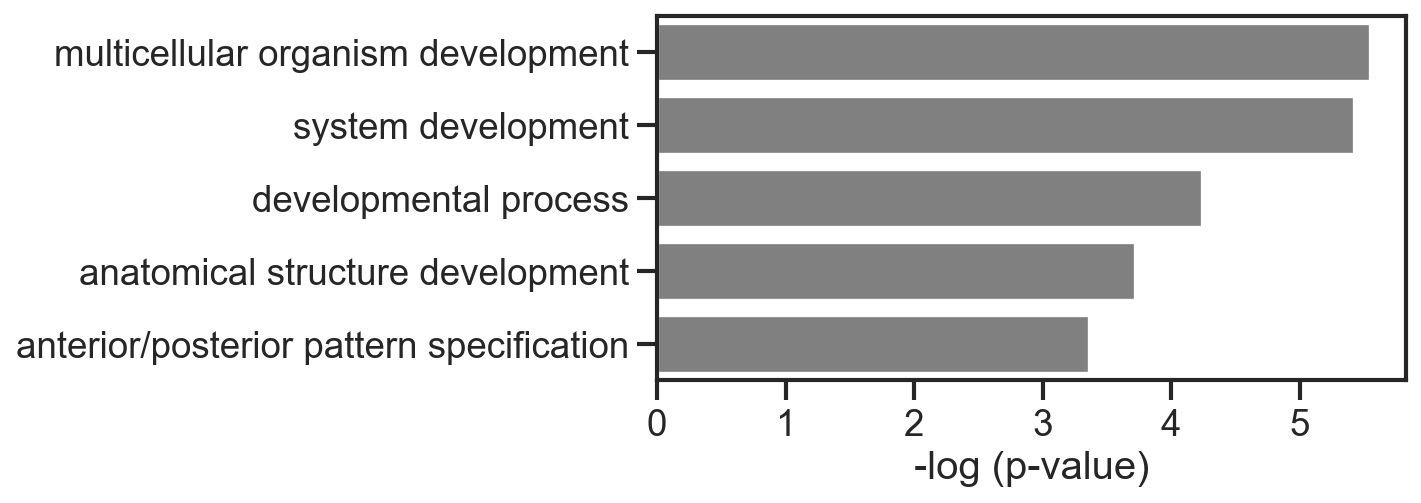

In [27]:
allgenes = list(PvsDIFF['Gene'].unique())
plotGO(list(PvsDIFF_up['Gene']),allgenes, n = 5)
plotGO(list(PvsDIFF_down['Gene']),allgenes, n = 5)

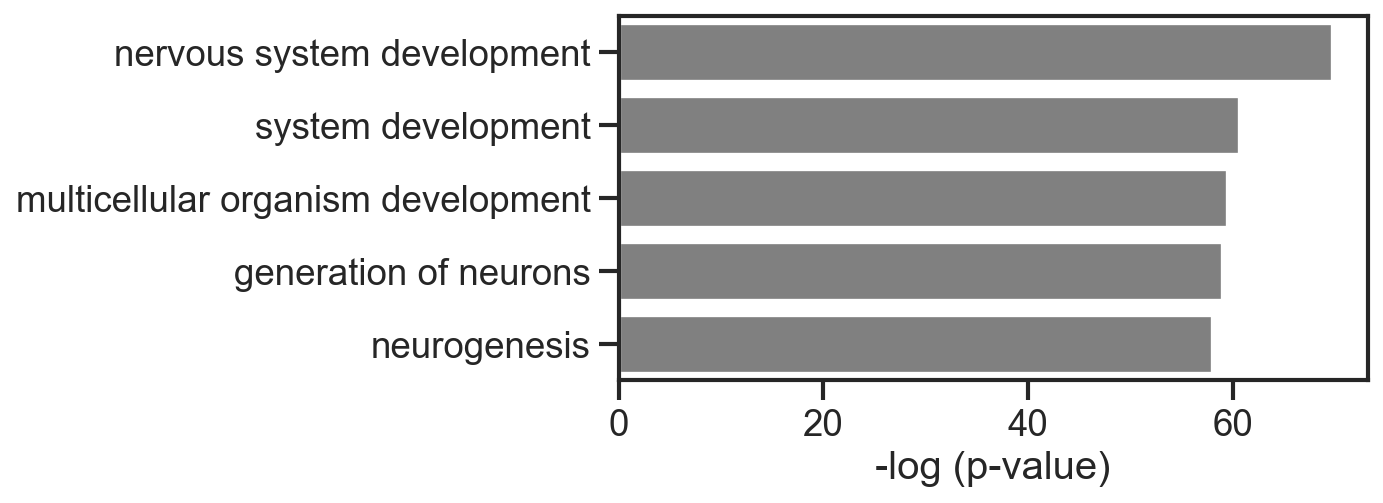

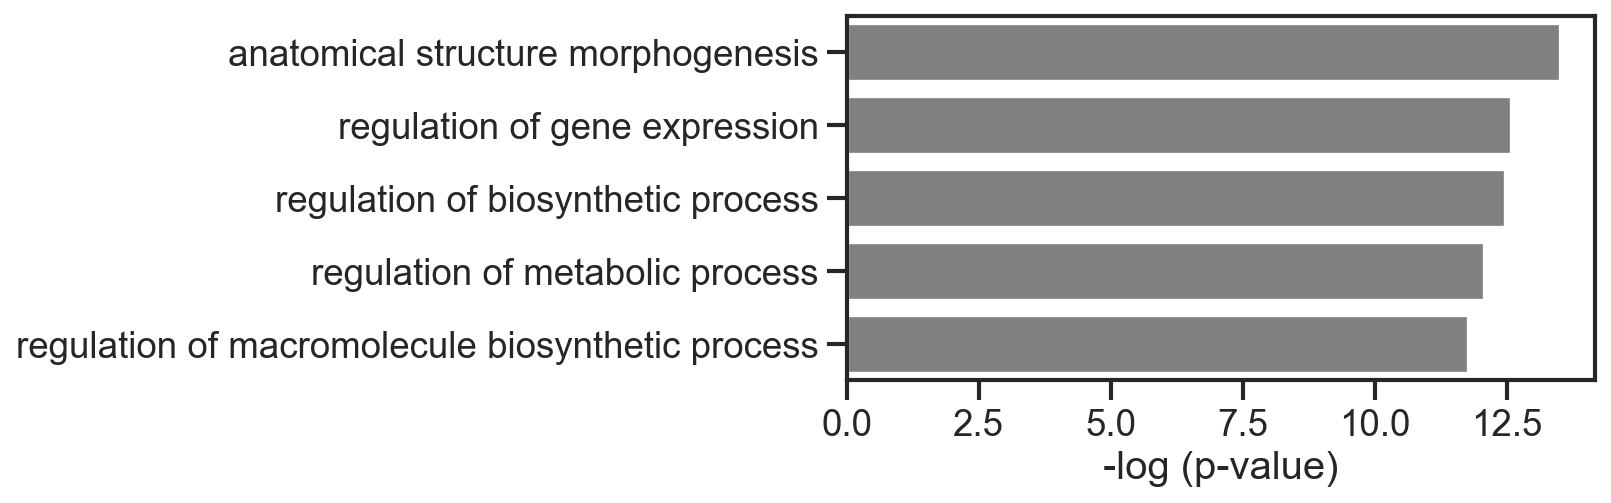

In [28]:
allgenes = list(PvsECT['Gene'].unique())
plotGO(list(PvsECT_up['Gene']),allgenes, n = 5)
plotGO(list(PvsECT_down['Gene']),allgenes, n = 5)

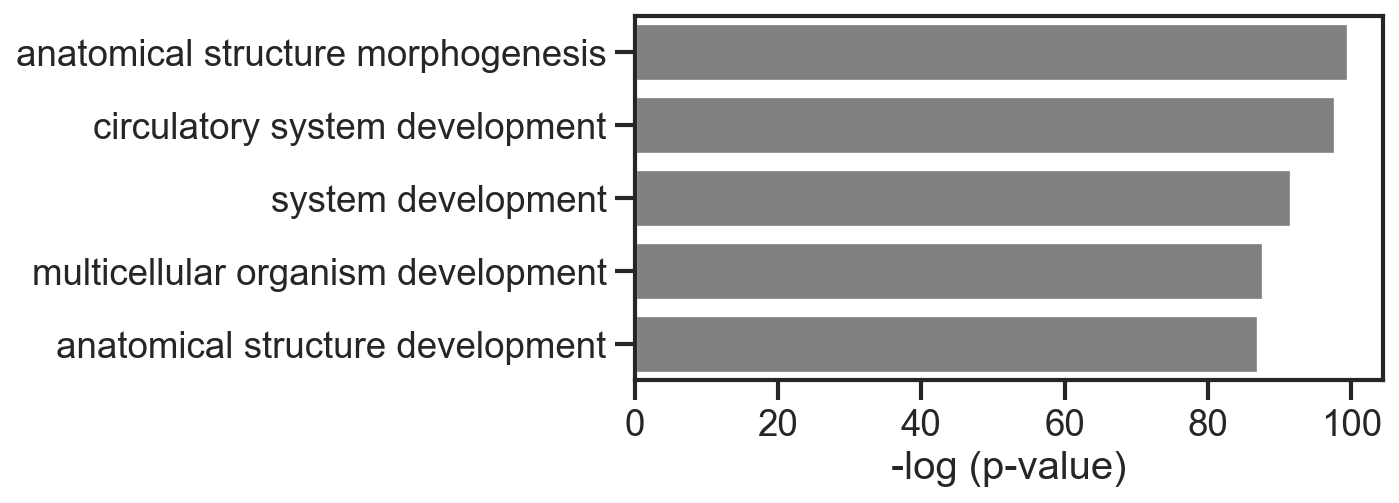

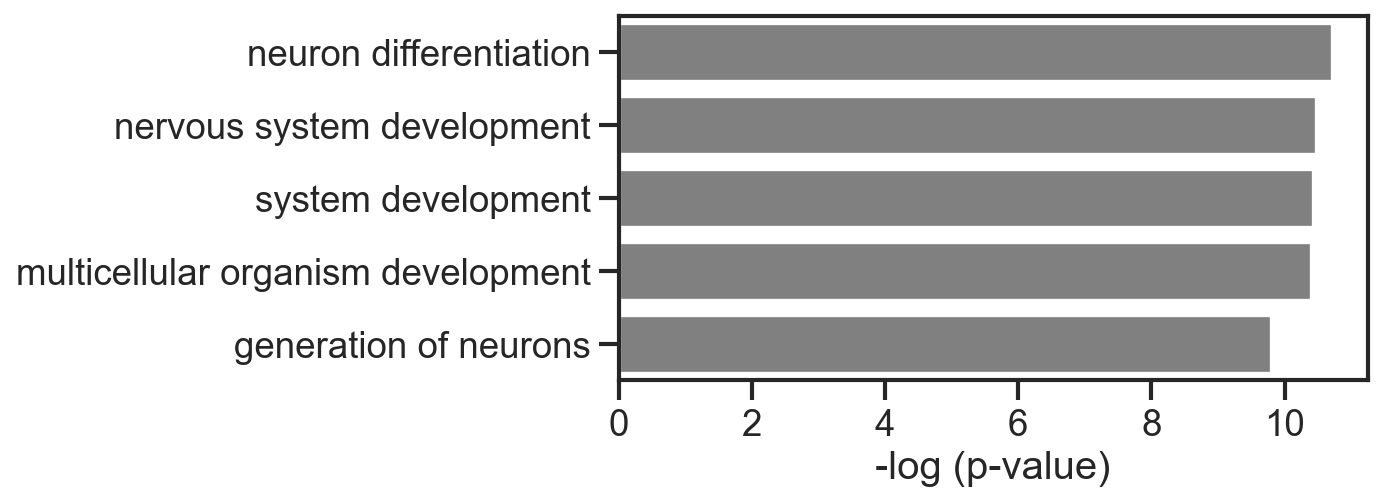

In [29]:
allgenes = list(PvsMES['Gene'].unique())
plotGO(list(PvsMES_up['Gene']),allgenes, n = 5)
plotGO(list(PvsMES_down['Gene']),allgenes, n = 5)

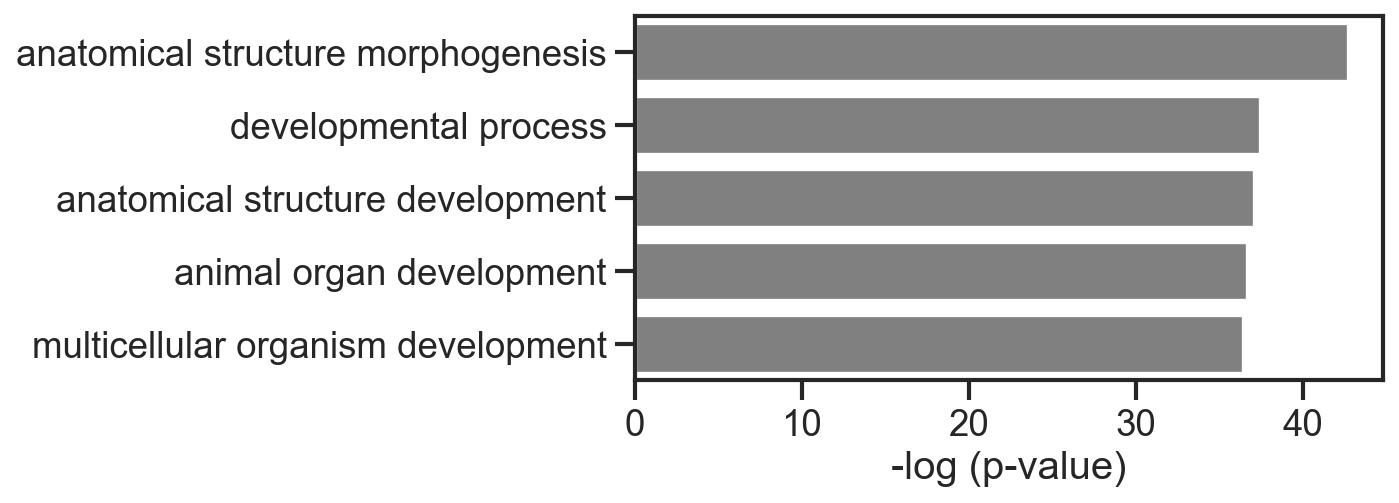

In [ ]:
allgenes = list(PvsEND['Gene'].unique())
plotGO(list(PvsEND_up['Gene']),allgenes, n = 5)
plotGO(list(PvsEND_down['Gene']),allgenes, n = 5)

## venn diagrams: check intersect between genesets

In [ ]:
from matplotlib_venn import venn3, venn3_circles

A = PvsECT_down['Gene']
B = PvsEND_down['Gene']
C = PvsMES_down['Gene']

fig,ax = plt.subplots(figsize = (3,3))
venn3([set(A),set(B),set(C)],ax=ax, set_colors = list(color_pal.values())[0:3],set_labels = list(color_pal.keys())[0:3],
      alpha = 0.7)
c = venn3_circles([set(A),set(B),set(C)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

plt.savefig('figs/20250305_venn_overlap_lineages_down.png',bbox_inches='tight')
plt.show()

In [ ]:
from matplotlib_venn import venn3, venn3_circles

A = PvsECT_up['Gene']
B = PvsEND_up['Gene']
C = PvsMES_up['Gene']

fig,ax = plt.subplots(figsize = (3,3))
venn3([set(A),set(B),set(C)],ax=ax, set_colors = list(color_pal.values())[0:3],set_labels = list(color_pal.keys())[0:3],
      alpha = 0.7)
c = venn3_circles([set(A),set(B),set(C)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

plt.savefig('figs/20250305_venn_overlap_lineages_up.png',bbox_inches='tight')
plt.show()

In [ ]:
from matplotlib_venn import venn2, venn2_circles
comparisons = [[PvsDIFF_down, PvsECT_down], [PvsDIFF_down, PvsEND_down], [PvsDIFF_down, PvsMES_down], [PvsDIFF_down, ESCvsP_down], [PvsDIFF_down, ESCvsP_up]]
lins = ['Ectoderm','Endoderm','Mesoderm', 'mESC','mESC']
for num,[a,b] in enumerate(comparisons):
    print(num)
    A = a['Gene']
    B = b['Gene']

    fig,ax = plt.subplots(figsize = (3,3))
    venn2([set(A),set(B)], ax=ax, set_colors = [color_pal['Pluripotent'],color_pal[lins[num]]],set_labels = ['pluripotent',lins[num]],
      alpha = 0.7)
    c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

    plt.show()

comparisons = [[PvsDIFF_up, PvsECT_up], [PvsDIFF_up, PvsEND_up], [PvsDIFF_up, PvsMES_up], [PvsDIFF_up, ESCvsP_down], [PvsDIFF_up, ESCvsP_up]]
for num,[a,b] in enumerate(comparisons):
    print(num)
    A = a['Gene']
    B = b['Gene']

    fig,ax = plt.subplots(figsize = (3,3))
    venn2([set(A),set(B)], ax=ax, set_colors = [color_pal['Pluripotent'],color_pal[lins[num]]],set_labels = ['pluripotent',lins[num]],
      alpha = 0.7)
    c = venn2_circles([set(A),set(B)],color = 'black',linewidth = 1,ax=ax, 
      alpha = 0.6)

    plt.show()
    

In [ ]:
sc.set_figure_params(dpi = 80)

sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

In [ ]:
cols[0]

# Take only unique differentially expressed genes

For the lineages, we take the "up" fraction - these are upregulated in lin vs pluripotent. \
For pluripotency, we take the "down" fraction in p vs diff - these are downregulated in the lineages compared to pluripotency, i.e. they are up in pluripotency. \
For ESCs, we take the "down" fraction in ESC vs p - these are donwregulated in ESCs compared to P. The "up" fraction is differentially expresssed in pluripotent compared to ESCs.

In [ ]:
ecto = PvsECT_up[~PvsECT_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsMES_up['Gene']))]
meso = PvsMES_up[~PvsMES_up['Gene'].isin(list(PvsEND_up['Gene']) + list(PvsECT_up['Gene']))]
endo = PvsEND_up[~PvsEND_up['Gene'].isin(list(PvsECT_up['Gene']) + list(PvsMES_up['Gene']))]
pluri = PvsDIFF_down

In [ ]:
makeVolcano(PvsECT, ecto,PvsECT_down, cols = [color_pal['Ectoderm'],color_pal['Pluripotent']], save = 'figs/20250305_volcano_PvsECT.png' )
makeVolcano(PvsMES, meso,PvsMES_down, cols = [color_pal['Mesoderm'],color_pal['Pluripotent']], save = 'figs/20250305_volcano_PvsMES.png' )
makeVolcano(PvsEND, endo,PvsEND_down, cols = [color_pal['Endoderm'],color_pal['Pluripotent']], save = 'figs/20250305_volcano_PvsEND.png' )
makeVolcano(PvsDIFF, PvsDIFF_up,pluri, cols = ['black',color_pal['Pluripotent']], save = 'figs/20250305_volcano_PvsDIFF.png' )
makeVolcano(ESCvsP, ESCvsP_up,ESCvsP_down, cols = [color_pal['Pluripotent'],color_pal['mESC']], save = 'figs/20250305_volcano_ESCvsP.png')

In [ ]:
plotGO(list(ecto['Gene']),list(PvsECT['Gene']), n = 5, col = color_pal['Ectoderm'], save = 'figs/20250305_GO_ect.png')
plotGO(list(meso['Gene']),list(PvsMES['Gene']), n = 5, col = color_pal['Mesoderm'], save = 'figs/20250305_GO_mes.png')
plotGO(list(endo['Gene']),list(PvsEND['Gene']), n = 5, col = color_pal['Endoderm'], save = 'figs/20250305_GO_end.png')
plotGO(list(PvsDIFF_down['Gene']),list(PvsDIFF['Gene']), n = 5, col = color_pal['Pluripotent'], save = 'figs/20250305_GO_PvsDIFF.png')
plotGO(list(ESCvsP_up['Gene']),list(ESCvsP['Gene']), n = 5, col = color_pal['Pluripotent'], save = 'figs/20250305_GO_ESCvP_up.png')
plotGO(list(ESCvsP_down['Gene']),list(ESCvsP['Gene']), n = 5, col = color_pal['mESC'], save = 'figs/20250305_GO_ESCvP_down.png')

## Make TF activity plots

In [ ]:
# Retrieve CollecTRI gene regulatory network
import decoupler as dc
collectri = dc.get_collectri(organism='mouse', split_complexes=False,)

collectri.head(2)

In [ ]:
def plotTFs(df, save = None, cmap = 'coolwarm', minmax = 3, lim = 5):
    df.index = df['Gene']
    mat = df[['stat']].T.rename(index={'stat': 'diff'})
    tf_acts, tf_pvals = dc.run_ulm(mat=mat, net=collectri)
    fig,ax=plt.subplots(figsize = (3,6))
    ax.set_xlim([-lim,lim])
    dc.plot_barplot(
    acts=tf_acts,
    contrast='diff',vmin = -minmax, vmax = minmax, 
    top=20,cmap = cmap,
    vertical=True,
    figsize=(3, 6),ax=ax,
    )
    if save != None:
        plt.savefig(save, bbox_inches = 'tight')
    plt.show()

In [ ]:
cols = ['#3787c0', '#fc6832','#df2179', '#58b669','lightgrey', 'teal']
pal_ect = sns.blend_palette(["#58b669",'lightgrey', '#3787c0'], as_cmap=True)
pal_end = sns.blend_palette(["#58b669",'lightgrey', '#fc6832'], as_cmap=True)
pal_mes = sns.blend_palette(["#58b669",'lightgrey', '#df2179'], as_cmap=True)
pal_p = sns.blend_palette(["#58b669",'lightgrey', 'black'], as_cmap=True)
pal_esc = sns.blend_palette(["teal",'lightgrey', '#58b669'], as_cmap=True)

In [ ]:
plotTFs(PvsECT, cmap = pal_ect, lim = 10, save = 'figs/20250305_TF_all_ect.png')
plotTFs(PvsMES, cmap = pal_mes, lim = 10, save = 'figs/20250305_TF_all_mes.png')
plotTFs(PvsEND, cmap = pal_end, lim = 10, save = 'figs/20250305_TF_all_end.png')
plotTFs(PvsDIFF, cmap = pal_p, lim = 10, save = 'figs/20250305_TF_all_p.png')
plotTFs(ESCvsP, cmap = pal_esc, lim = 10, save = 'figs/20250305_TF_all_esc.png')

In [ ]:
plotTFs(ecto, cmap = pal_ect, save = 'figs/20250305_TF_unique_ect.png')

In [ ]:
plotTFs(meso, cmap = pal_mes, save = 'figs/20250305_TF_unique_mes.png')

In [ ]:
plotTFs(endo, cmap = pal_end, save = 'figs/20250305_TF_unique_end.png')

In [ ]:
plotTFs(pluri, cmap = pal_p, save = 'figs/20250305_TF_unique_p.png')

# make heatmaps and so on

In [ ]:
pwd

In [ ]:
metadata = pd.read_csv('../../../tchic_local/fig6_build/dfs/20250215_metadata.tsv', index_col = 0, header = 0, low_memory= False, sep = '\t')

In [ ]:
metadata.head(2)

In [ ]:
pwd

In [50]:
count_table = pd.read_csv('../../../tchic_local/fig6_build/dfs/20250304_count_data_all_thresh_min.tsv', sep = '\t', index_col = 0)

In [51]:
count_table.index = count_table['gene']
count_table.head(2)

,gene,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn
gene,,,,,,,,,,
Xkr4,Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0
Rp1,Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0


In [52]:
d_rna = {}
d_k4 = {}
d_k27 = {}
df_rna = count_table[count_table['layer'] == 'RNA']
df_k4 = count_table[count_table['layer'] == 'K4']
df_k27 = count_table[count_table['layer'] == 'K27']

df_rna = df_rna.drop('gene',axis=1)
df_k4 = df_k4.drop('gene',axis=1)
df_k27 = df_k27.drop('gene',axis=1)

In [53]:
df_rna['p_99'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],99)
df_k4['p_99'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],99)
df_k27['p_99'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],99)

df_rna['p_98'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],98)
df_k4['p_98'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],98)
df_k27['p_98'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],98)

df_rna['p_95'] = df_rna['sm_short']/np.percentile(df_rna['sm_short'],95)
df_k4['p_95'] = df_k4['sm_short']/np.percentile(df_k4['sm_short'],95)
df_k27['p_95'] = df_k27['sm_short']/np.percentile(df_k27['sm_short'],95)

In [54]:
ct_normalised = pd.concat([df_rna,df_k4,df_k27])

In [55]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95
gene,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,0.047819,0.069934,0.125110
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0,0.046809,0.068456,0.122467


In [56]:
ct_normalised['p98_log2'] = np.log2(ct_normalised['p_98']+1)
ct_normalised['p98_log10'] = np.log10(ct_normalised['p_98']+1)

ct_normalised['step_id'] = ct_normalised['step'].astype(str) + str(':') + ct_normalised['lin']
metadata['step_id'] = metadata['step'].astype(str) + str(':') + metadata['lin']
steps_to_RT = metadata[['step_id','RT']].set_index('step_id').to_dict()['RT']
ct_normalised['RT'] = ct_normalised['step_id'].map(steps_to_RT)
ct_normalised['RT'] = ct_normalised['RT'].astype('category')
ct_normalised['RT'] = ct_normalised['RT'].cat.reorder_categories(['mESCs','Gastd3', 'Gastd4', 'Gastd5', 'Gastd6', 'Gastd7'])
ct_normalised['lin_layer'] = ct_normalised['lin'].astype(str) + str('_') + ct_normalised['layer'].astype(str)


In [57]:
ct_normalised.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95,p98_log2,p98_log10,step_id,RT,lin_layer
gene,,,,,,,,,,,,,,,,,
Xkr4,1,RNA,0.25,ect1,0.284,-1.943416,-1.766112,1.0,0.0,0.047819,0.069934,0.125110,0.097521,0.029357,1:ect1,mESCs,ect1_RNA
Rp1,1,RNA,0.23,ect1,0.278,-2.058894,-1.795859,1.0,1.0,0.046809,0.068456,0.122467,0.095528,0.028757,1:ect1,mESCs,ect1_RNA


In [58]:
to_plot1 = ct_normalised.loc[list(set(endo['Gene']) & set(ct_normalised.index))]
to_plot2 = ct_normalised.loc[list(set(meso['Gene']) & set(ct_normalised.index))]
to_plot3 = ct_normalised.loc[list(set(ecto['Gene']) & set(ct_normalised.index))]
to_plot4 = ct_normalised.loc[list(set(pluri['Gene']) & set(ct_normalised.index))]

In [59]:
lin_colors = {'Ectoderm':'#3787C0', 'Endoderm':'#FC6832', 'Mesoderm':'#DF2179'}
Green='#238b45'
Purple='#6a51a3'
Orange='#d94801'

lightOrange = '#f59c71'
lightGreen = '#90f5b1'
lightPurple = '#b698fa'

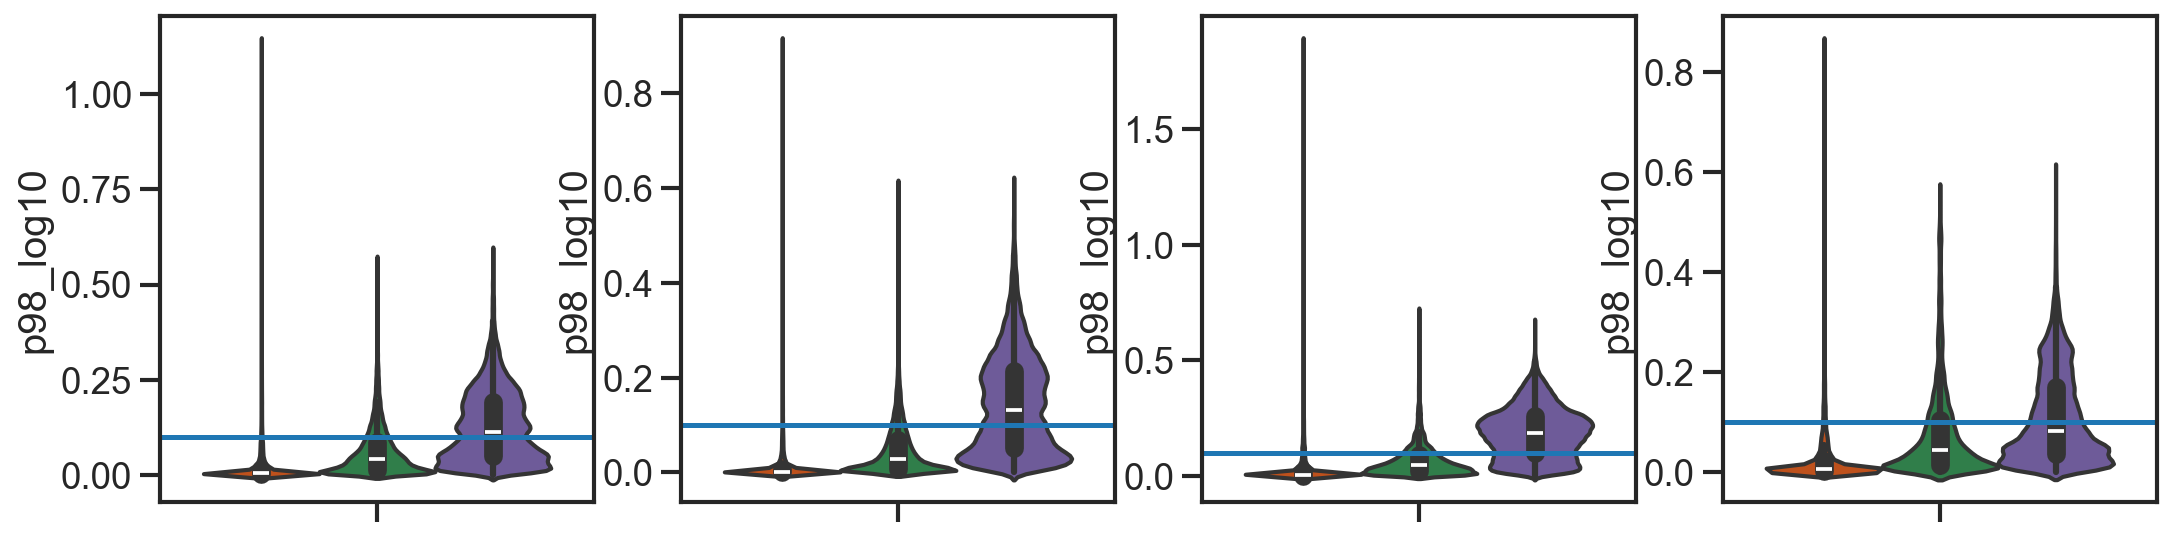

In [60]:
fig,ax=plt.subplots(1,4,figsize = (16,4))
plotting = [to_plot1,to_plot2,to_plot3,to_plot4]
for num,p in enumerate(plotting):
    sns.violinplot(data = p[['layer','p98_log10']],
                hue = 'layer',ax=ax[num],
                y = 'p98_log10',
                   legend=False,
                  palette = [Orange,Green,Purple])
    ax[num].axhline(0.1)

plt.show()

In [61]:
ct_normalised.loc['Sox17'][['layer','lin','sm_short_state_dyn']].value_counts()

layer  lin    sm_short_state_dyn
RNA    ect3   0.0                   170
K27    ect3   1.0                   170
RNA    mes2   0.0                   165
K27    mes2   1.0                   165
       ect1   1.0                   161
RNA    ect1   0.0                   161
       ect2   0.0                   142
K27    ect2   1.0                   142
       mes1   1.0                   133
RNA    mes1   0.0                   133
K27    mes3   1.0                   131
RNA    mes3   0.0                   123
K4     mes3   1.0                   102
       endo1  1.0                    97
       mes1   1.0                    88
       ect3   1.0                    86
       mes2   1.0                    85
       ect2   1.0                    85
       ect3   0.0                    84
       ect1   1.0                    83
       mes2   0.0                    80
       ect1   0.0                    78
K27    endo1  1.0                    75
RNA    endo1  0.0                    69
K4     

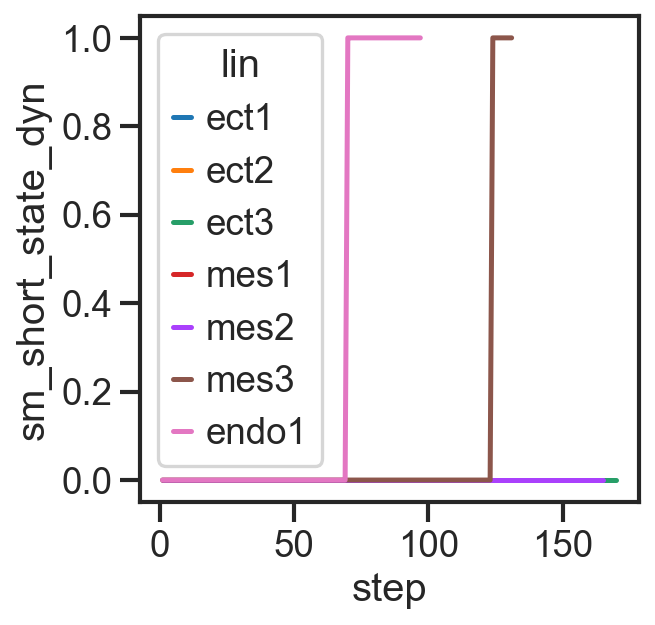

In [62]:
gene = 'Sox17'
sns.lineplot(data = ct_normalised[(ct_normalised['layer'] == 'RNA') & (ct_normalised.index == 'Sox17')],
            x = 'step',
            y = 'sm_short_state_dyn',
            hue = 'lin')
plt.show()

In [63]:
def linePlotPerTrajectory(df,lin, genelist, hue = 'layer', xval = 'step', yval='p_99',save = None):
    #to_plot = df.loc[genelist]
    fig,ax = plt.subplots(figsize = (12,4))
  #  sns.lineplot(data = df[df['lin'] != lin], linewidth = 2,
  #               ax=ax,
  #                  x = xval,
  #                  y = yval,
  #                  hue = hue,alpha=0.5,
  #                  palette = [lightOrange,lightOrange,lightOrange,lightOrange,lightOrange,lightOrange,
  #                             lightGreen,lightGreen,lightGreen,lightGreen,lightGreen,lightGreen,
  #                             lightPurple,lightPurple,lightPurple,lightPurple,lightPurple,lightPurple],errorbar = None,)
                  # hue_order = ['RNA','K4','K27'])
    
    sns.lineplot(data = df[df['lin'] == lin], linewidth = 4,
                 ax=ax,
                    x = xval,
                    y = yval,
                    hue = 'layer',
                    palette = [Orange,Green, Purple],errorbar = None,
                   hue_order = ['RNA','K4','K27'])
    
    plt.legend([],frameon = False)
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()

In [64]:
gene = ['Sox17']
df_to_plot = ct_normalised.loc[gene]

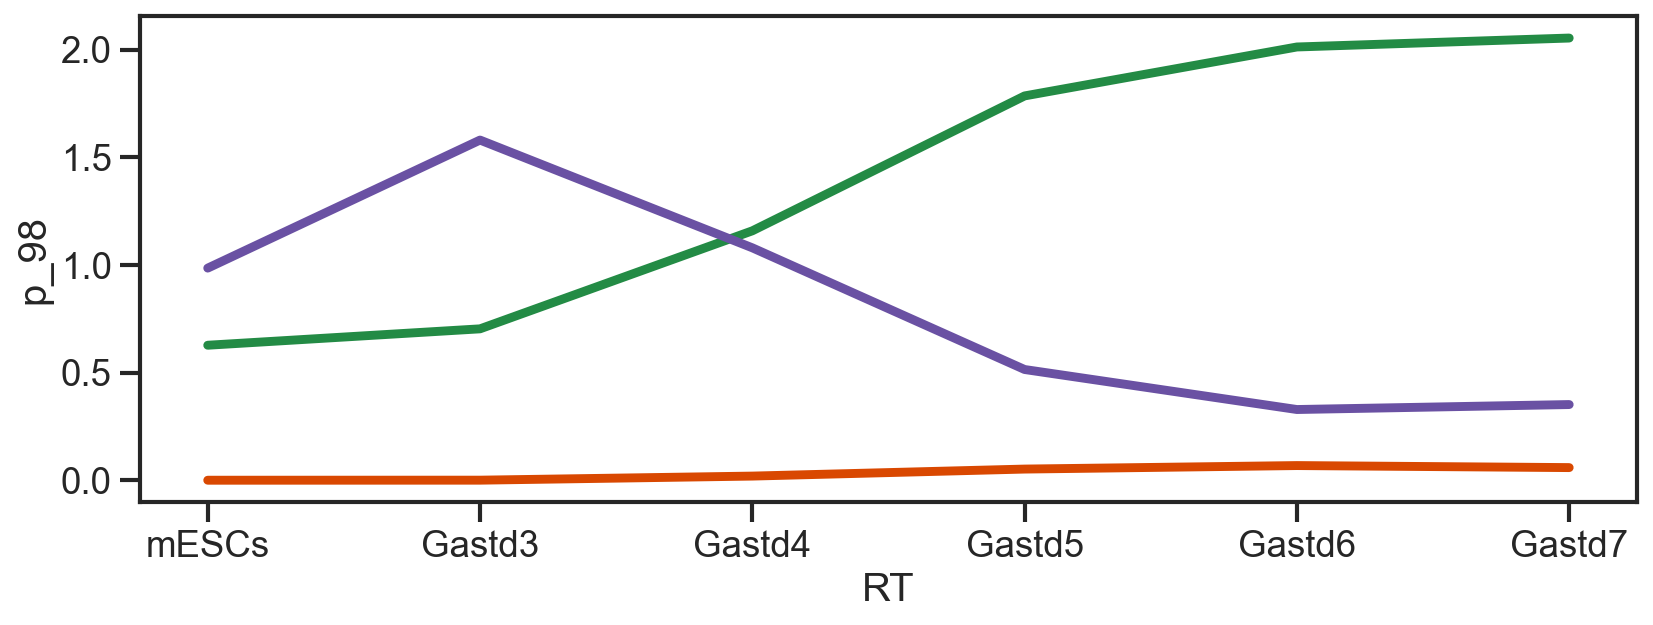

In [65]:
linePlotPerTrajectory(df_to_plot, 'endo1', gene, hue = 'lin_layer', xval = 'RT',yval='p_98')

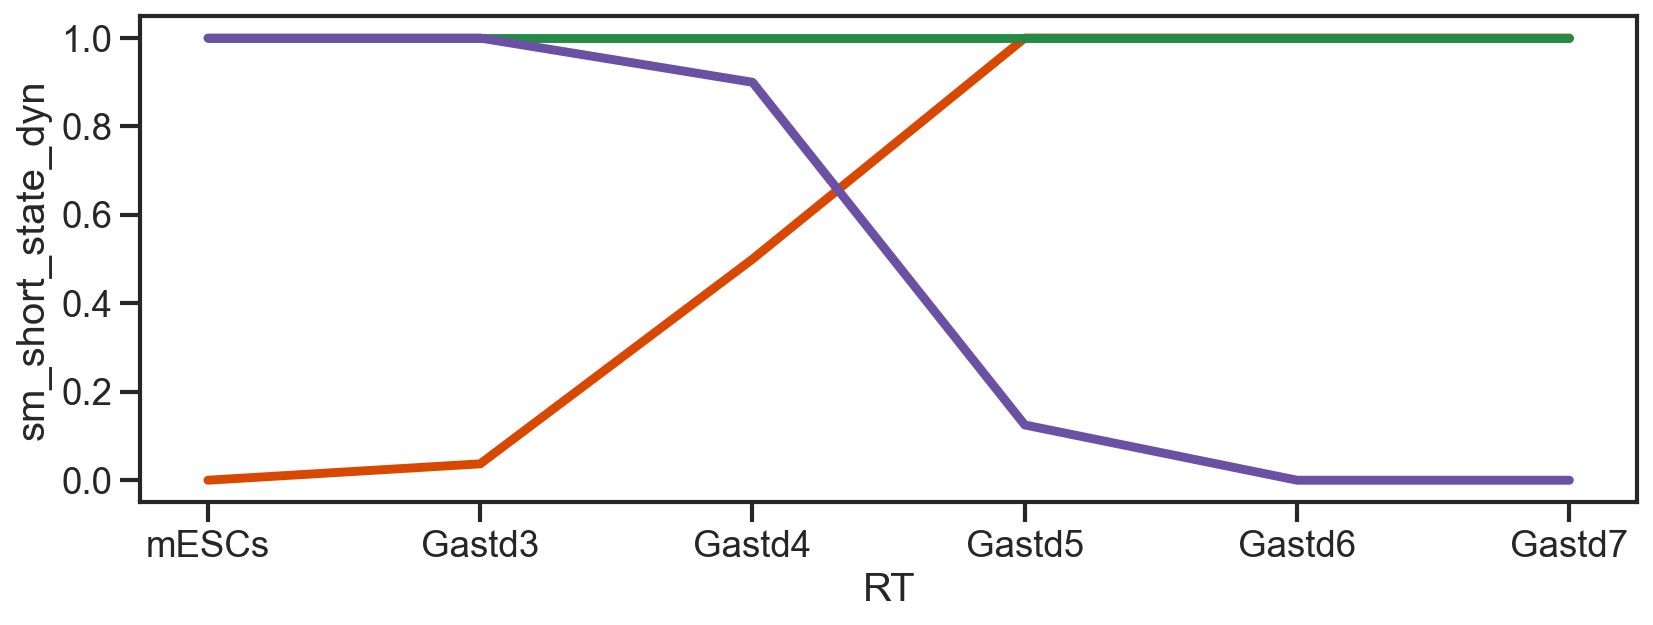

In [66]:
linePlotPerTrajectory(df_to_plot, 'endo1', gene, hue = 'lin_layer', xval = 'RT',yval='sm_short_state_dyn')

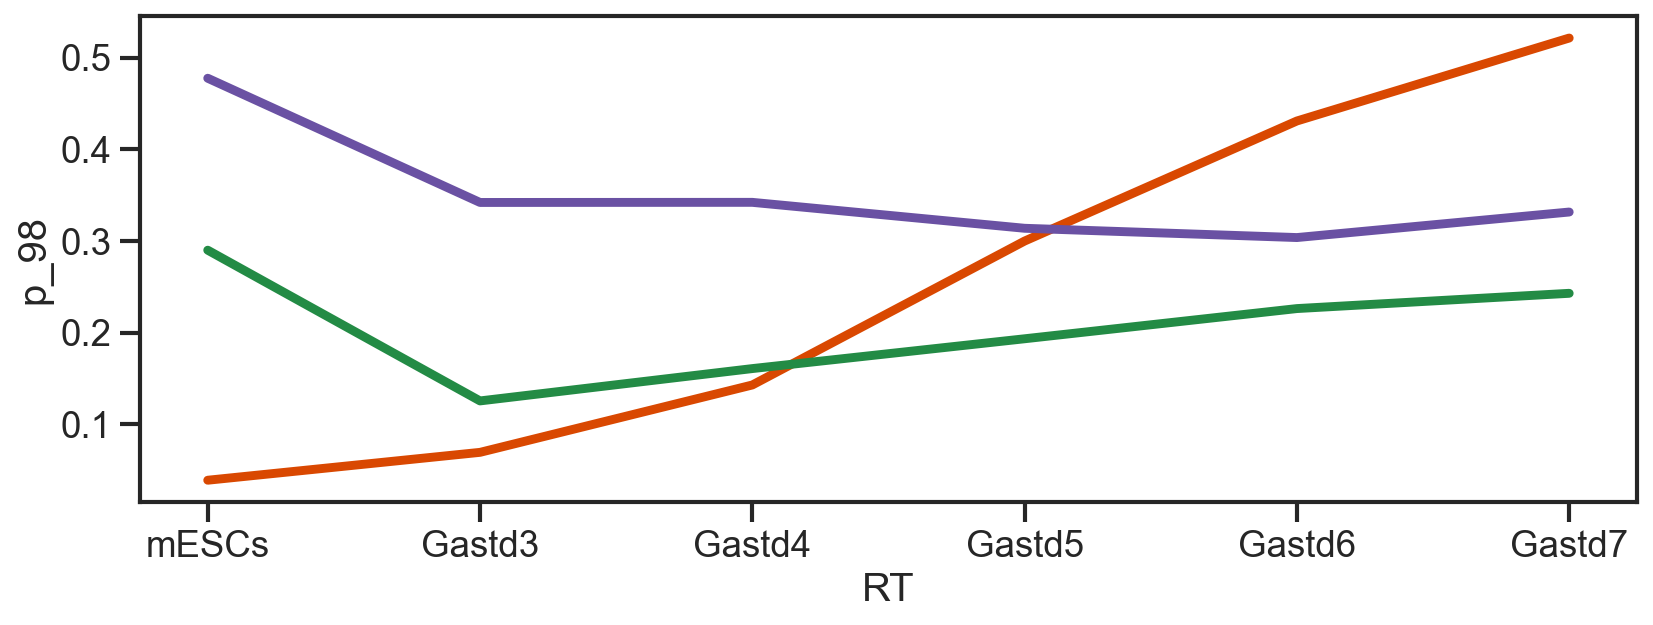

In [67]:
linePlotPerTrajectory(to_plot1, 'endo1', endo['Gene'], hue = 'lin_layer', xval = 'RT',yval='p_98')

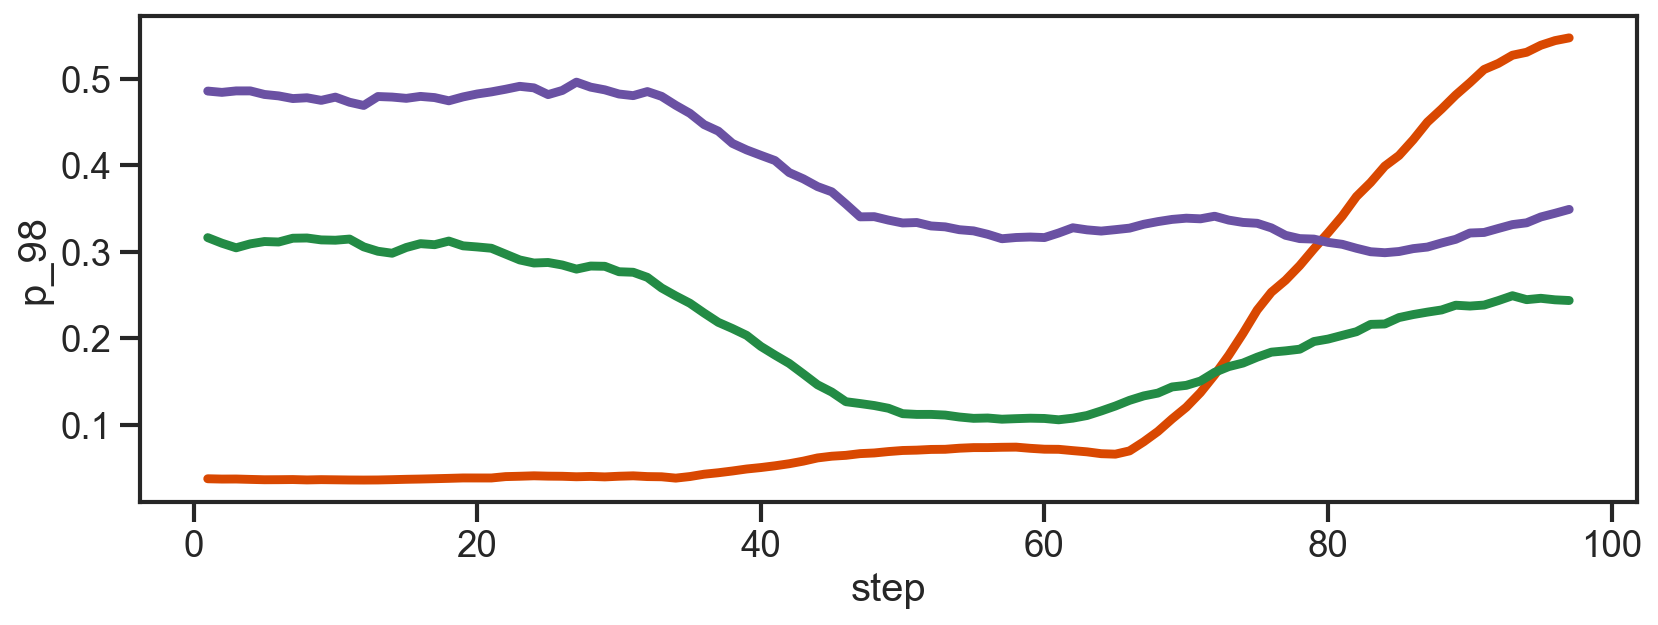

In [68]:
linePlotPerTrajectory(to_plot1, 'endo1', endo['Gene'], hue = 'lin_layer', xval = 'step',yval='p_98')

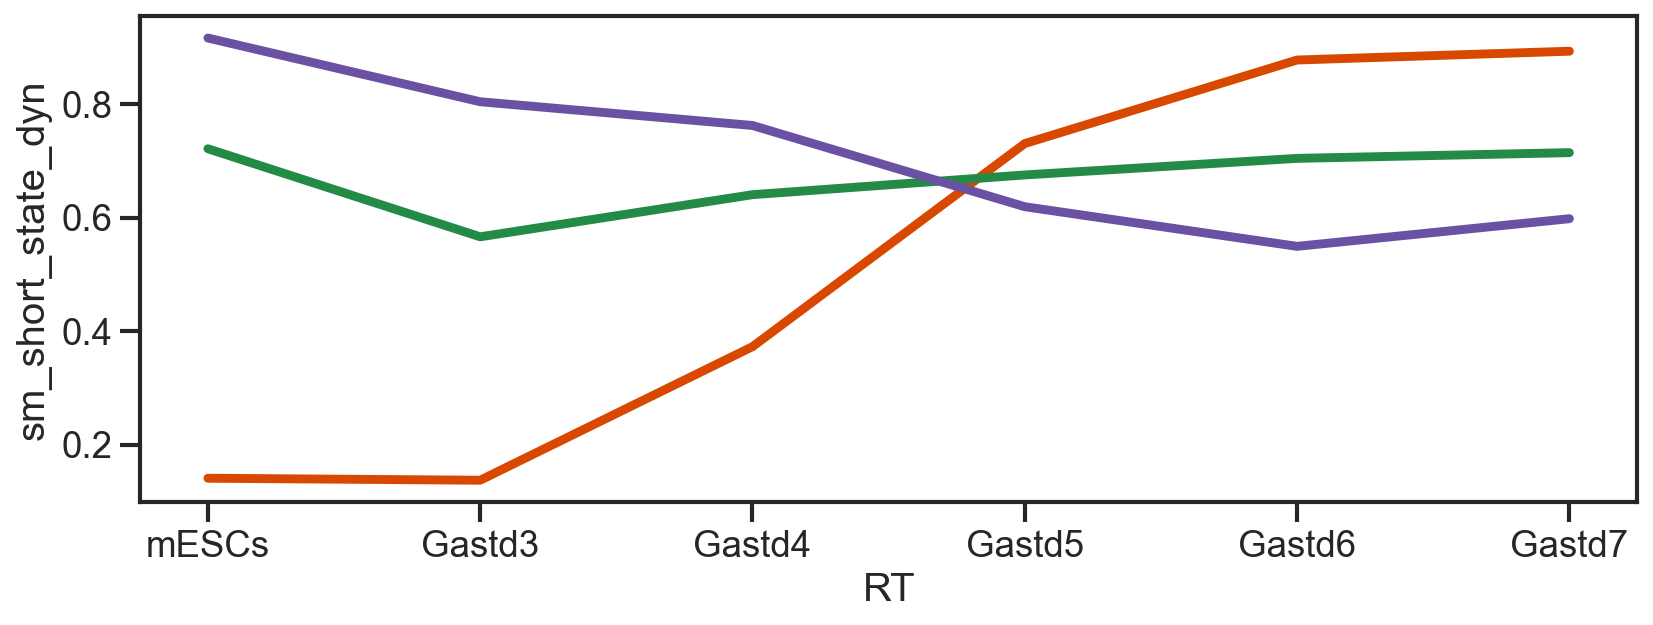

In [69]:
linePlotPerTrajectory(to_plot1, 'endo1', endo['Gene'], hue = 'lin_layer', xval = 'RT',yval='sm_short_state_dyn')

In [70]:
to_plot1.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95,p98_log2,p98_log10,step_id,RT,lin_layer
gene,,,,,,,,,,,,,,,,,
Atp8a2,1,RNA,0.20,ect1,0.24,-2.251539,-2.0,1.0,0.0,0.040411,0.059099,0.105727,0.082837,0.024936,1:ect1,mESCs,ect1_RNA
Atp8a2,2,RNA,0.18,ect1,0.24,-2.395929,-2.0,1.0,0.0,0.040411,0.059099,0.105727,0.082837,0.024936,2:ect1,mESCs,ect1_RNA


In [71]:
ct_normalised['lin'].unique()

array(['ect1', 'ect2', 'ect3', 'mes1', 'mes2', 'mes3', 'endo1'],
      dtype=object)

In [72]:
greens_r = sns.blend_palette(['black','#238b45', '#75c477', '#c8e9c1' ], as_cmap = True)
purples_r = sns.blend_palette(['black','#6a51a3', '#9e9bc8', '#dadaeb'], as_cmap = True)
oranges_r = sns.blend_palette(['black','#d94801', '#fd8e3d', '#fdd1a3'], as_cmap = True)

import scipy 

def plotheatmap(count_table, lineage = 'ect1',genelist = ['Onecut2'], val = 'sm',xval = 'step', save = None,aspect_ratio = 0.01):

    #f = count_table[(count_table['lin'] == lineage)].loc[genelist][[val, 'modality','step']]
    df = pd.pivot_table(count_table[count_table['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
    df = df[genelist]
    order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(df.T.fillna(0)))
    df = df.iloc[:,order]

    fig,ax=plt.subplots(4, 1, figsize=(12,len(genelist)*aspect_ratio), height_ratios = [0.4,0.2,0.2,0.2], 
                        gridspec_kw = {'wspace':0, 'hspace':0.05})
    

    df_rna = df.loc['RNA']
    df_k4 = df.loc['K4']
    df_k27 = df.loc['K27']
    
    df_k271 = pd.DataFrame(df_k27.unstack()).rename(columns={0:'vals'})
    df_k271['mod'] = 'k27'
    df_k41 = pd.DataFrame(df_k4.unstack()).rename(columns={0:'vals'})
    df_k41['mod'] = 'k4'
    df_rna1 = pd.DataFrame(df_rna.unstack()).rename(columns={0:'vals'})
    df_rna1['mod'] = 'rna'
        
    sns.lineplot(data = pd.concat([df_k271, df_k41, df_rna1]), ax=ax[0],
                    x = xval,
                    y = 'vals',
                    hue = 'mod',
                     hue_order = ['rna','k4','k27'],
                    palette = [Orange, Green, Purple])
    
    sns.heatmap(data = df_rna.T,#.iloc[order],
                cbar = False,vmax=0.2,
                ax=ax[1],
               cmap = oranges_r)
    sns.heatmap(data = df_k4.T,#.iloc[order],
                cbar = False,vmax = 0.4,
                ax=ax[2],
               cmap = greens_r)
    sns.heatmap(data = df_k27.T,#.iloc[order],
                cbar = False,vmax = 0.9,
                ax=ax[3],
               cmap = purples_r)
    for x in range(4):
        ax[x].legend([],frameon=False)
        ax[x].set_xticks([])
        ax[x].set_xlabel('')
        ax[x].set_yticks([])
        ax[x].set_ylabel('')   
    
    #ax[0].set_xlim(df_k271.index.get_level_values(xval).unique()[[0,-1]])
    ax[0].set_ylim([0,0.81])
    ax[0].set_yticks([0,0.2,0.4,0.6,0.8])
    ax[3].set_xlabel('pseudotime')
    ax[2].set_ylabel('genes')

    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()
    plt.close()


def plotheatmap_only(count_table, lineage = 'ect1',genelist = ['Onecut2'], val = 'sm', vmax_rna = 0.6, vmax_k4 = 0.5, vmax_k27 = 0.8,
                     xval = 'step', save = None,aspect_ratio = 0.01):

    #f = count_table[(count_table['lin'] == lineage)].loc[genelist][[val, 'modality','step']]
    df = pd.pivot_table(count_table[count_table['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
    df = df[genelist]
    order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(df.T.fillna(0)))
    df = df.iloc[:,order]

    fig,ax=plt.subplots(3, 1, figsize=(12,len(genelist)*aspect_ratio), height_ratios = [0.2,0.2,0.2], 
                        gridspec_kw = {'wspace':0, 'hspace':0.05})
    
    df_rna = df.loc['RNA']
    df_k4 = df.loc['K4']
    df_k27 = df.loc['K27']
    
    sns.heatmap(data = df_rna.T,#.iloc[order],
                cbar = False,vmax=vmax_rna,
                ax=ax[0],
               cmap = oranges_r)
    sns.heatmap(data = df_k4.T,#.iloc[order],
                cbar = False,vmax = vmax_k4,
                ax=ax[1],
               cmap = greens_r)
    sns.heatmap(data = df_k27.T,#.iloc[order],
                cbar = False,vmax = vmax_k27,
                ax=ax[2],
               cmap = purples_r)
    for x in range(3):
        ax[x].legend([],frameon=False)
        ax[x].set_xticks([])
        ax[x].set_xlabel('')
        ax[x].set_yticks([])
        ax[x].set_ylabel('')   
    
    ax[2].set_xlabel('pseudotime')
    ax[1].set_ylabel('genes')

    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()
    plt.close()


def plotline(count_table, lineage = 'ect1',genelist = ['Onecut2'], val = 'sm',xval = 'step', save = None,figsize = (4,4)):

    df = pd.pivot_table(count_table[count_table['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
    fig,ax=plt.subplots(figsize=(figsize))
    

    df_rna = df.loc['RNA']
    df_k4 = df.loc['K4']
    df_k27 = df.loc['K27']

    df_rna = df_rna[genelist]
    df_k4 = df_k4[genelist]
    df_k27 = df_k27[genelist]
    
    # order = scipy.cluster.hierarchy.leaves_list(scipy.cluster.hierarchy.linkage(df.T.fillna(0)))
    df_k271 = pd.DataFrame(df_k27.unstack()).rename(columns={0:'vals'})
    df_k271['mod'] = 'k27'
    df_k41 = pd.DataFrame(df_k4.unstack()).rename(columns={0:'vals'})
    df_k41['mod'] = 'k4'
    df_rna1 = pd.DataFrame(df_rna.unstack()).rename(columns={0:'vals'})
    df_rna1['mod'] = 'rna'
        
    sns.lineplot(data = pd.concat([df_k271, df_k41, df_rna1]), ax=ax,
                    x = xval,
                    y = 'vals',
                    hue = 'mod',
                     hue_order = ['rna','k4','k27'],
                    palette = [Orange, Green, Purple])
    

    ax.legend([],frameon=False)
    
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')   
    
    #ax[0].set_xlim(df_k271.index.get_level_values(xval).unique()[[0,-1]])
    ax.set_ylim([0,1])
    ax.set_yticks([0,0.2,0.4,0.6,0.8,1.0])
    if save != None:
        plt.savefig(save , bbox_inches='tight')
    plt.show()
    plt.close()

In [73]:
to_plot1.head(2)

,step,layer,counts,lin,sm_short,counts_log2,sm_short_log2,sm_short_state_fix,sm_short_state_dyn,p_99,p_98,p_95,p98_log2,p98_log10,step_id,RT,lin_layer
gene,,,,,,,,,,,,,,,,,
Atp8a2,1,RNA,0.20,ect1,0.24,-2.251539,-2.0,1.0,0.0,0.040411,0.059099,0.105727,0.082837,0.024936,1:ect1,mESCs,ect1_RNA
Atp8a2,2,RNA,0.18,ect1,0.24,-2.395929,-2.0,1.0,0.0,0.040411,0.059099,0.105727,0.082837,0.024936,2:ect1,mESCs,ect1_RNA


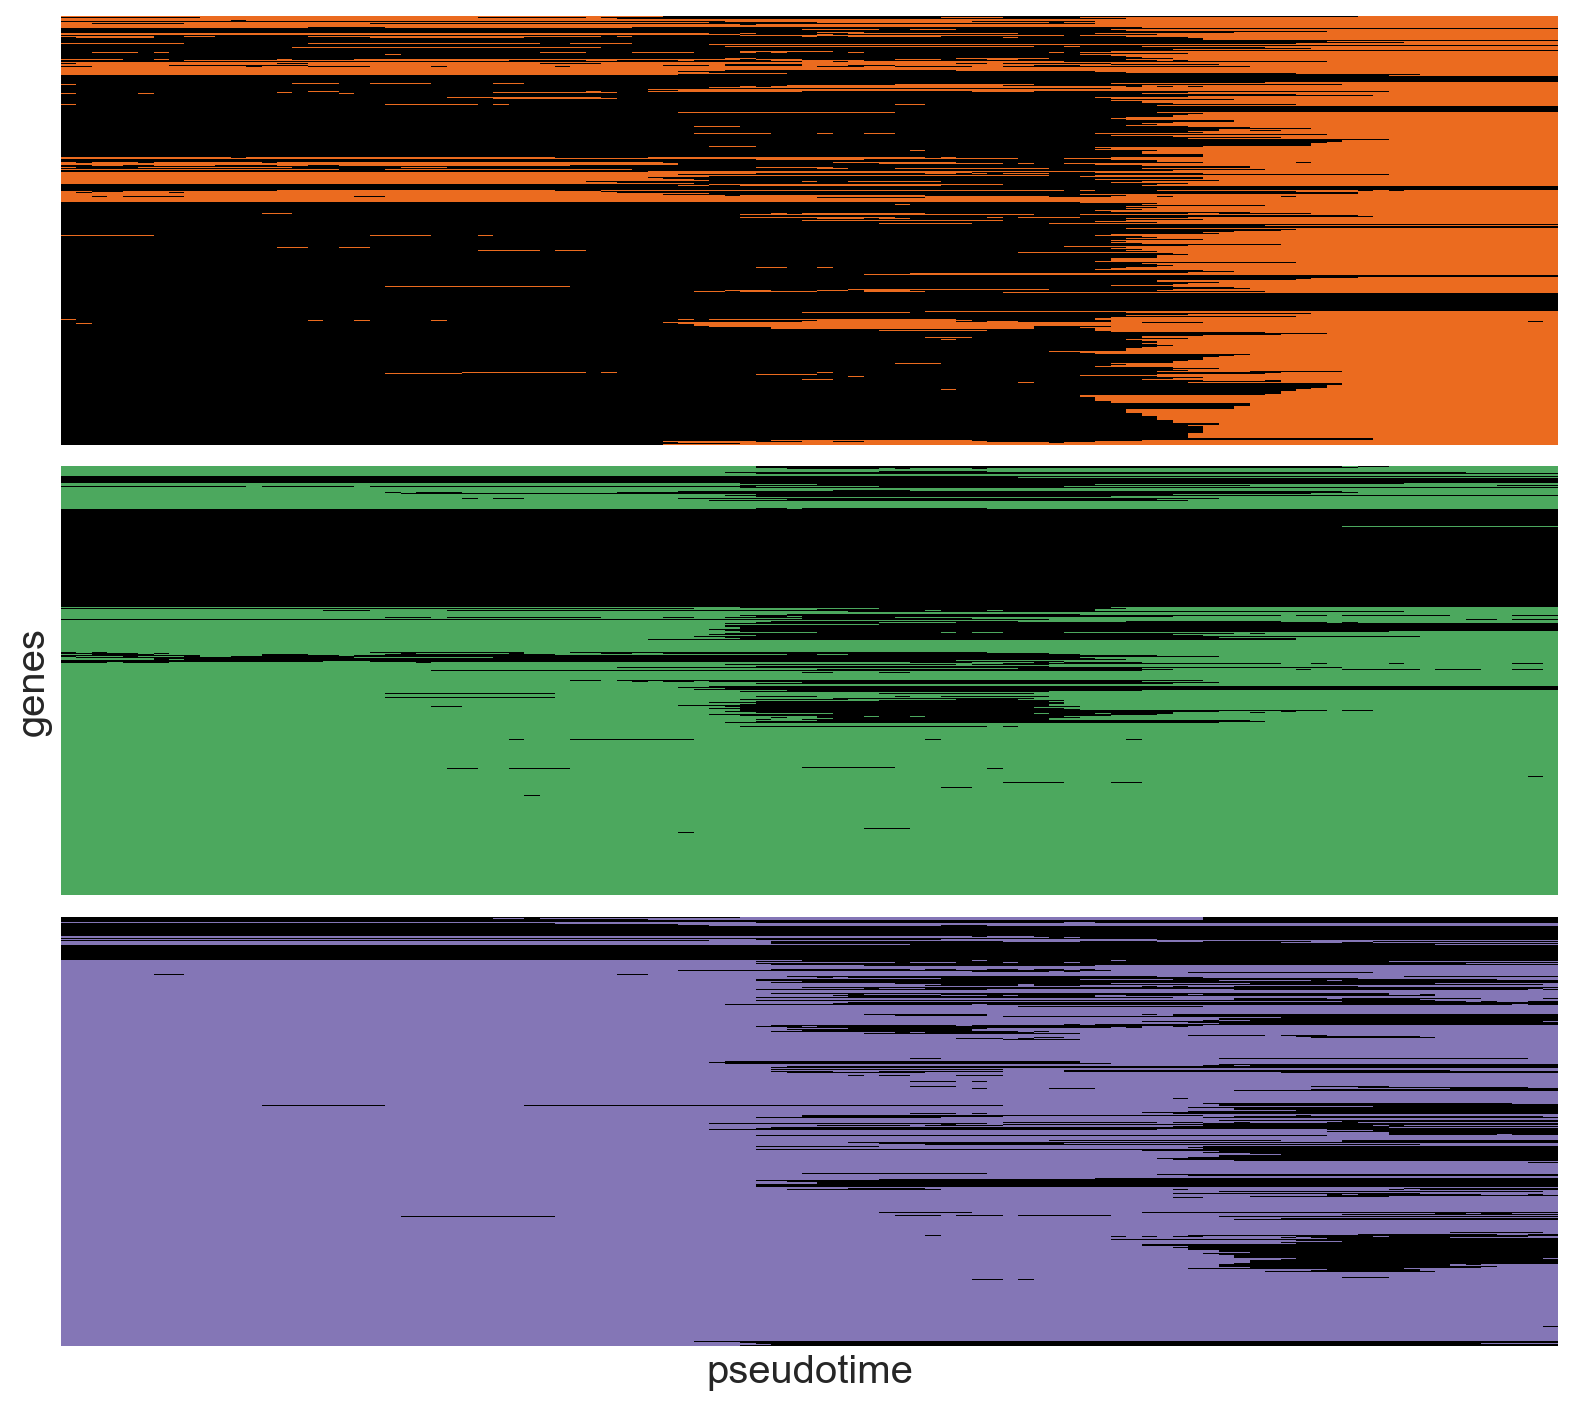

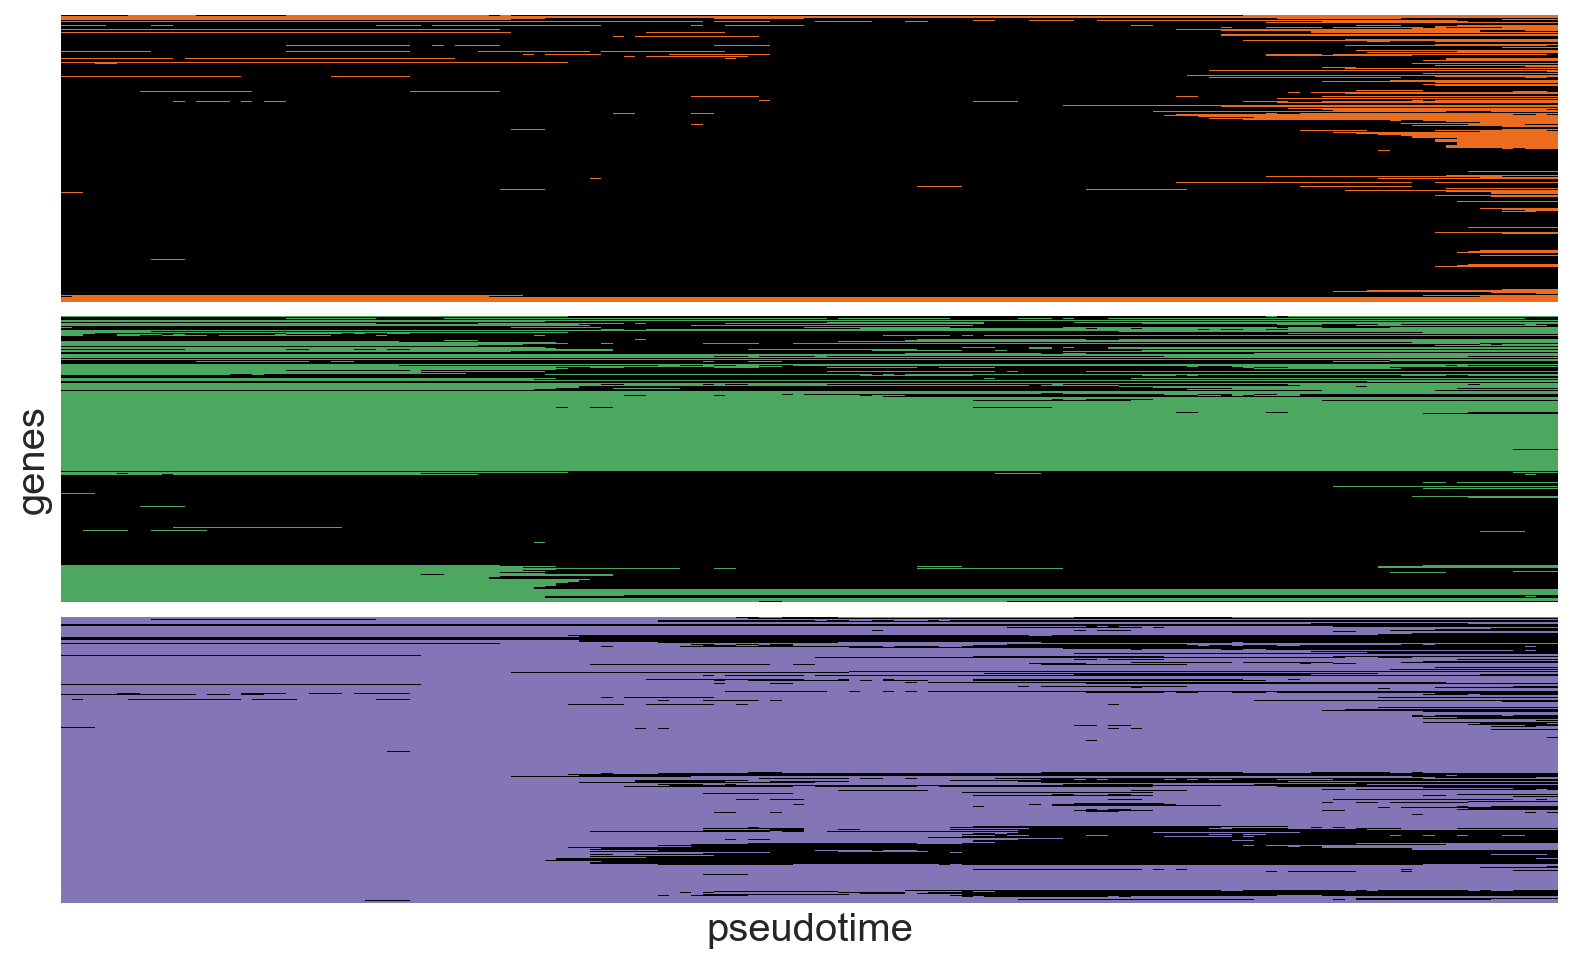

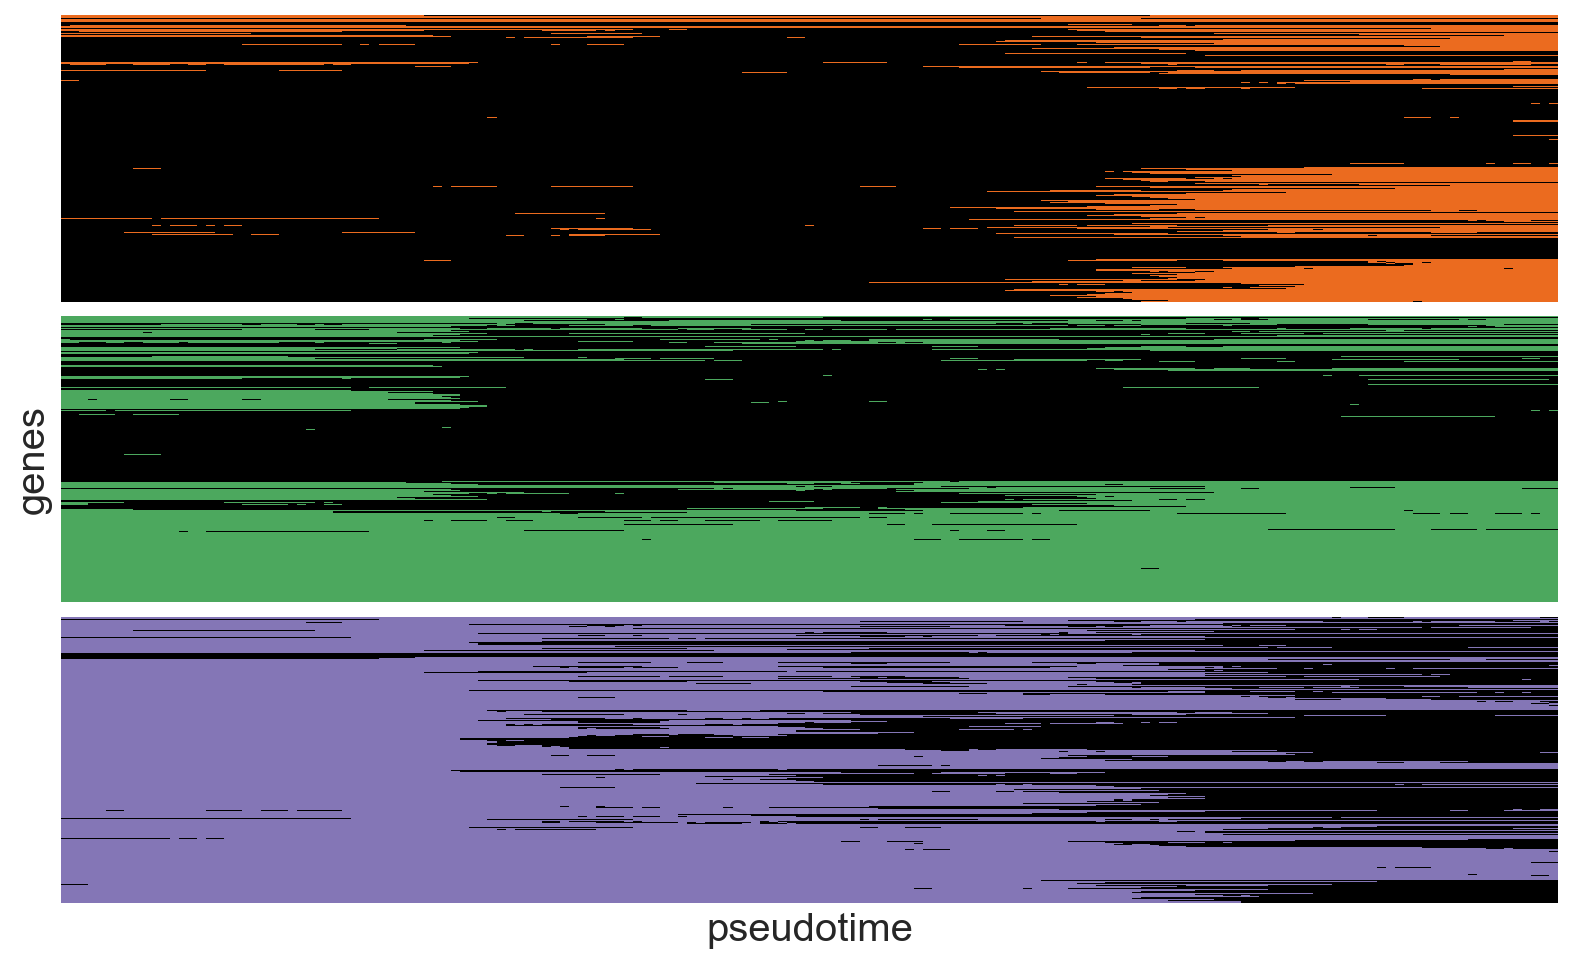

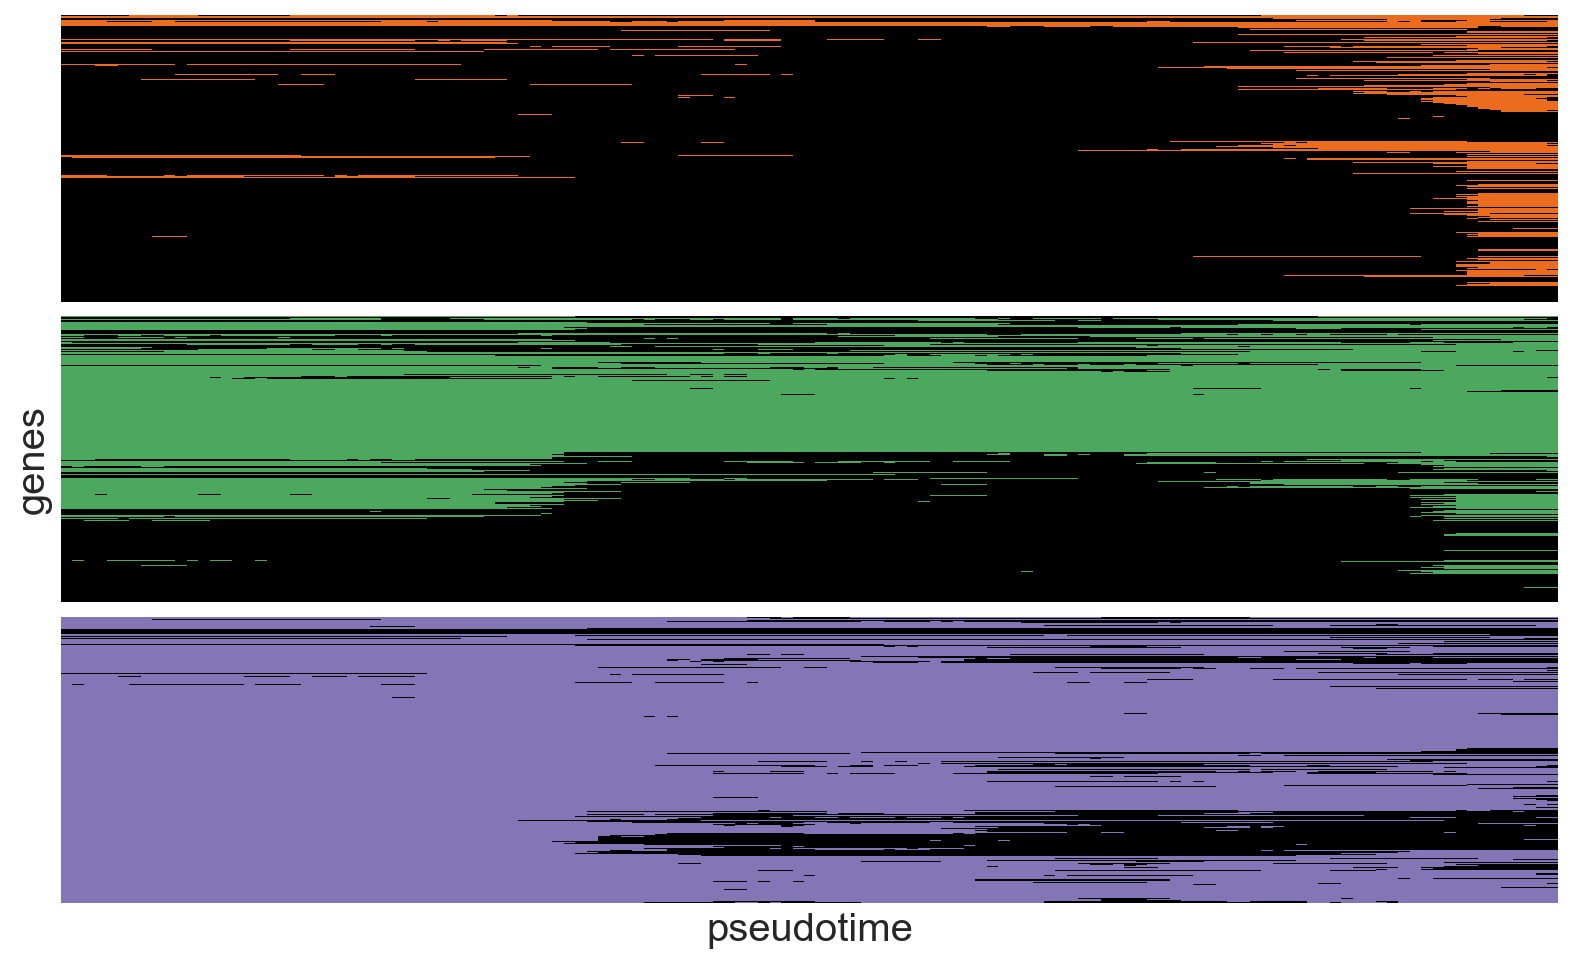

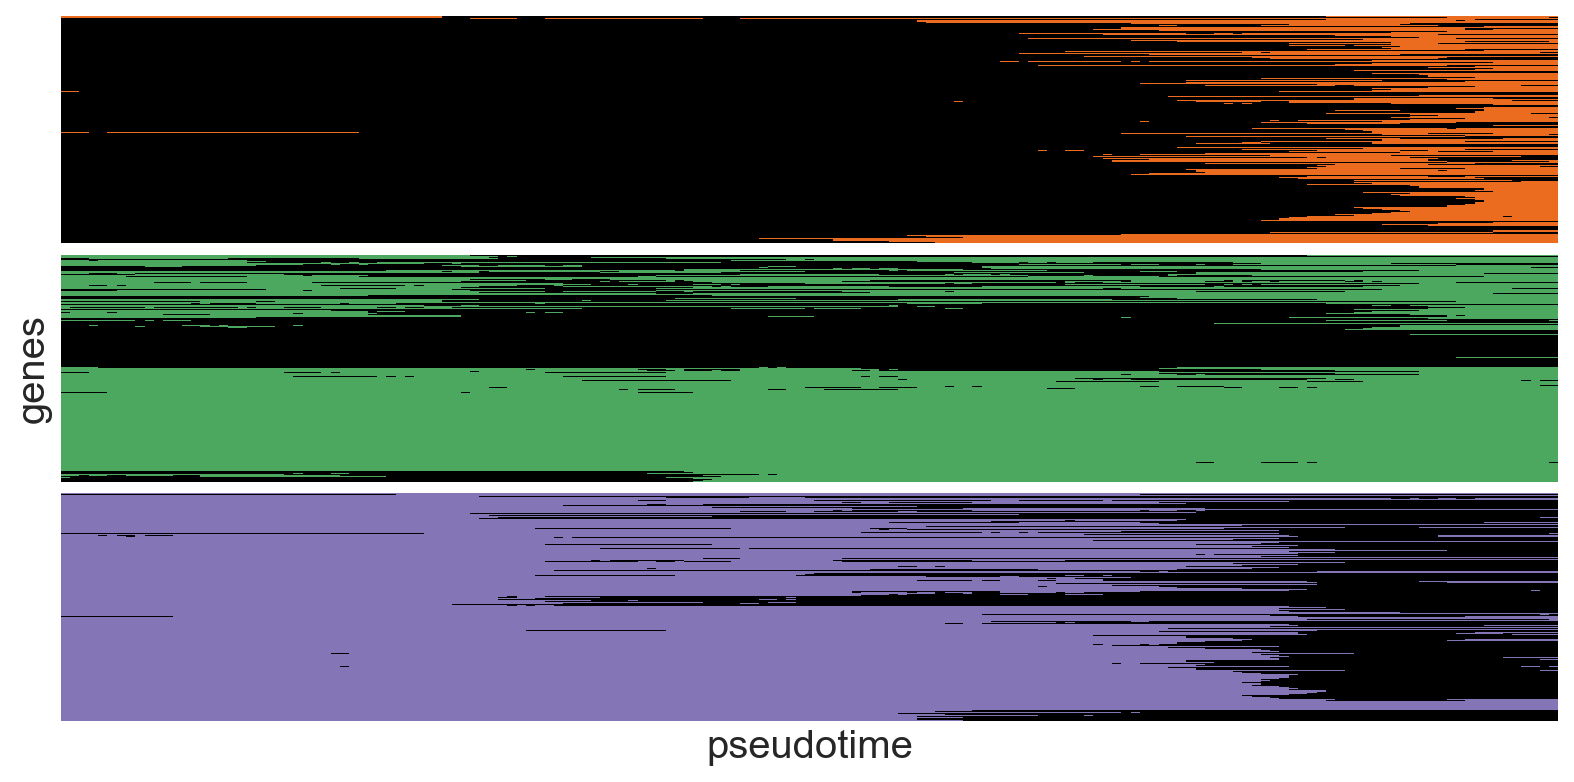

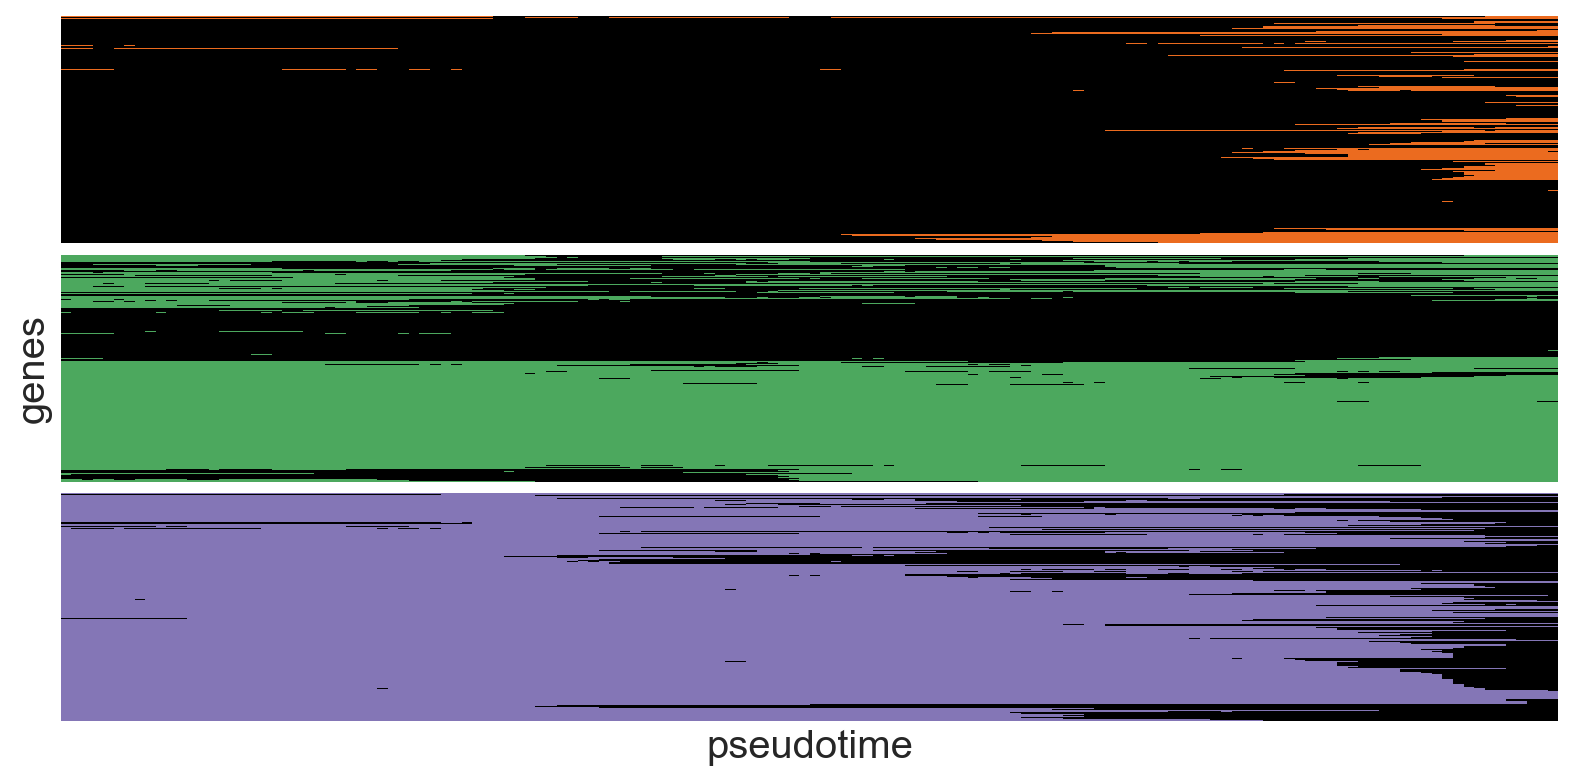

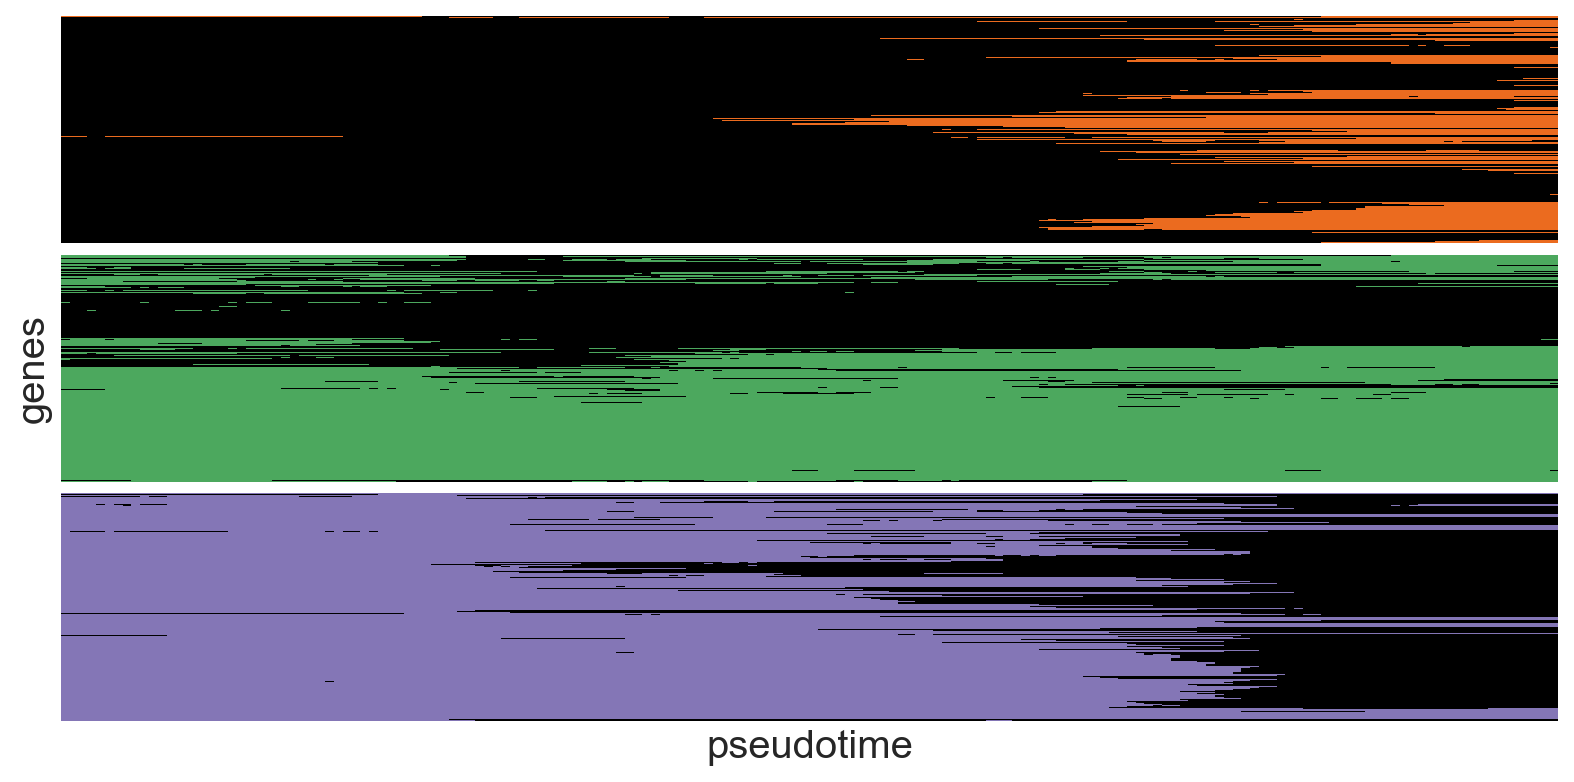

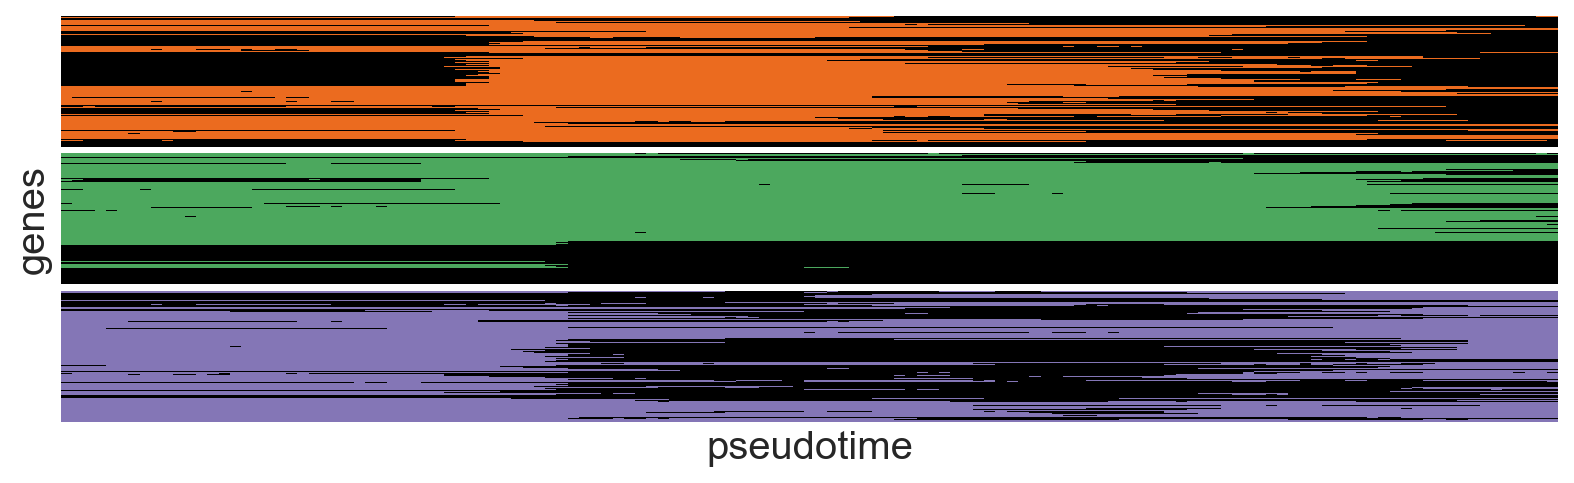

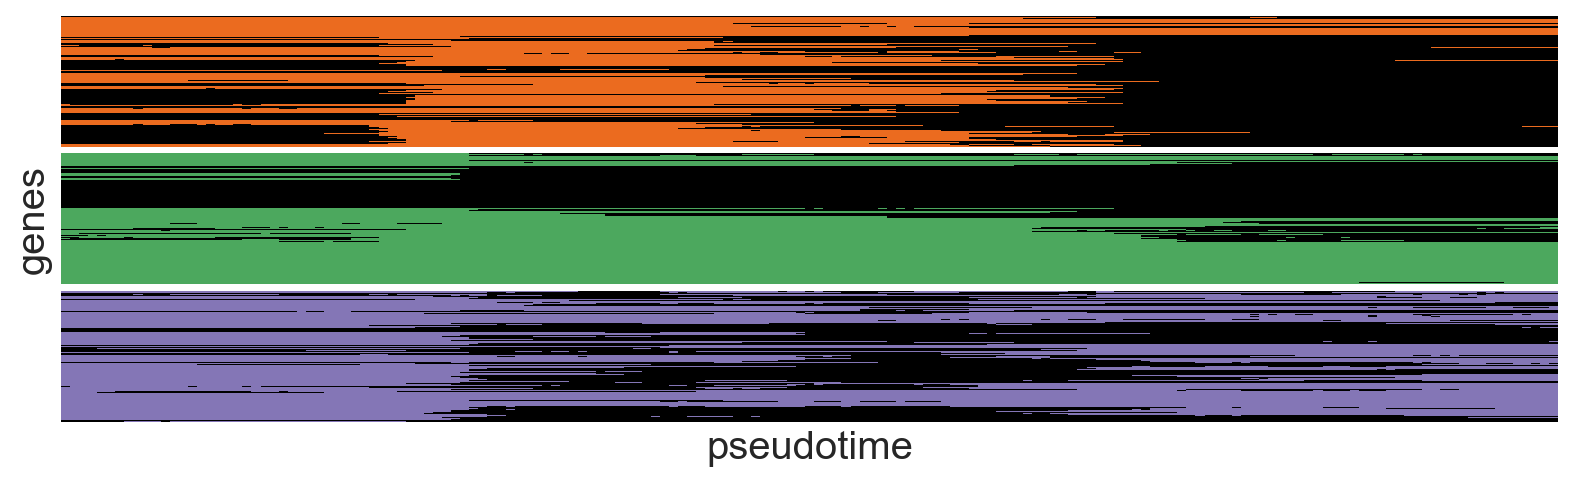

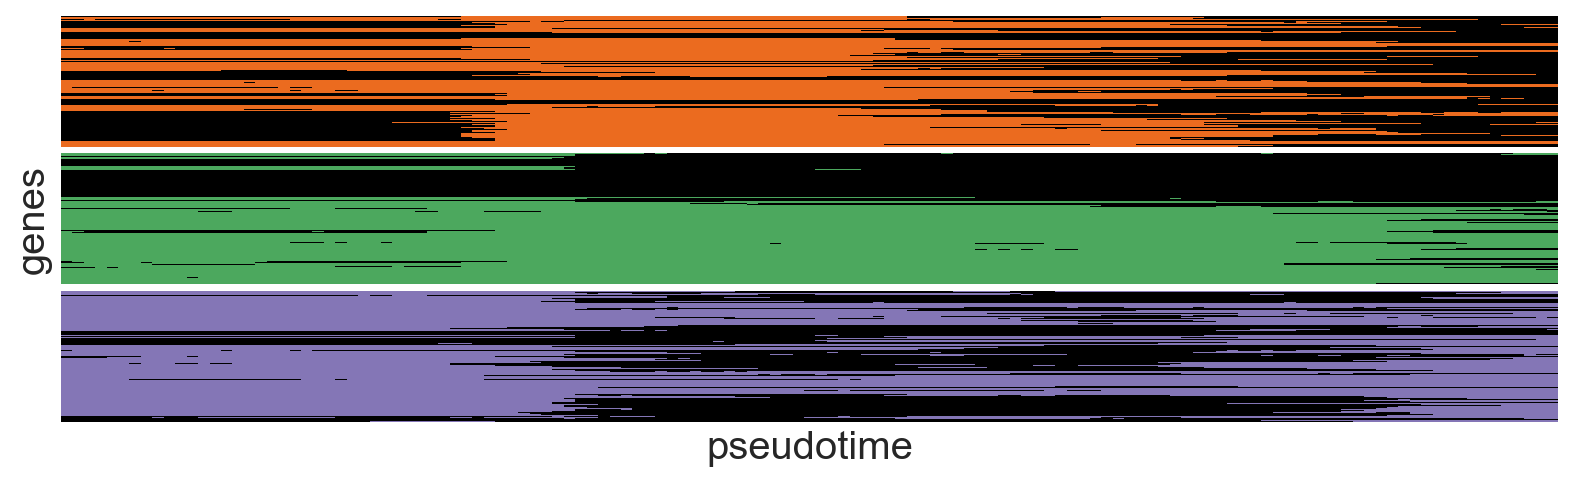

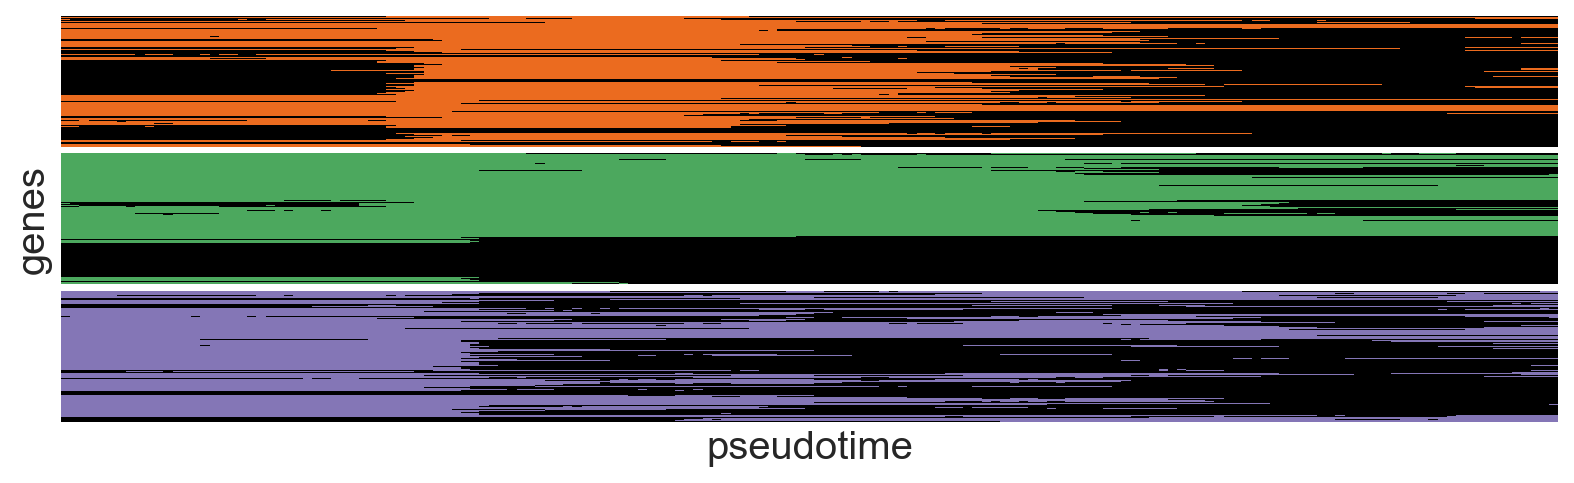

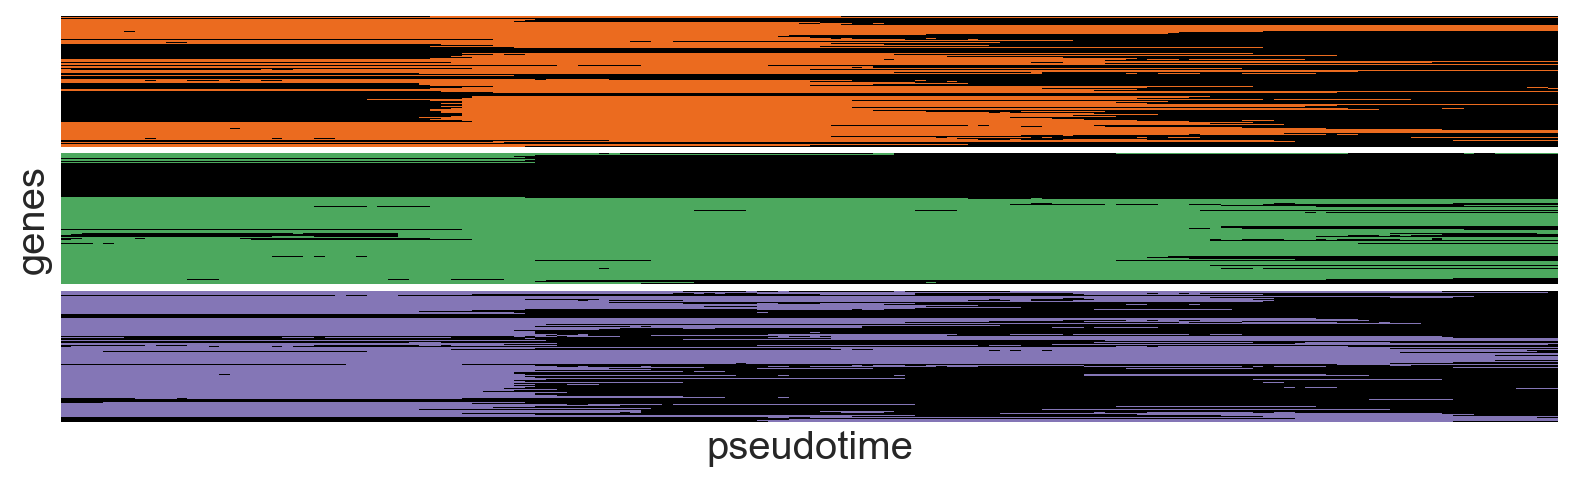

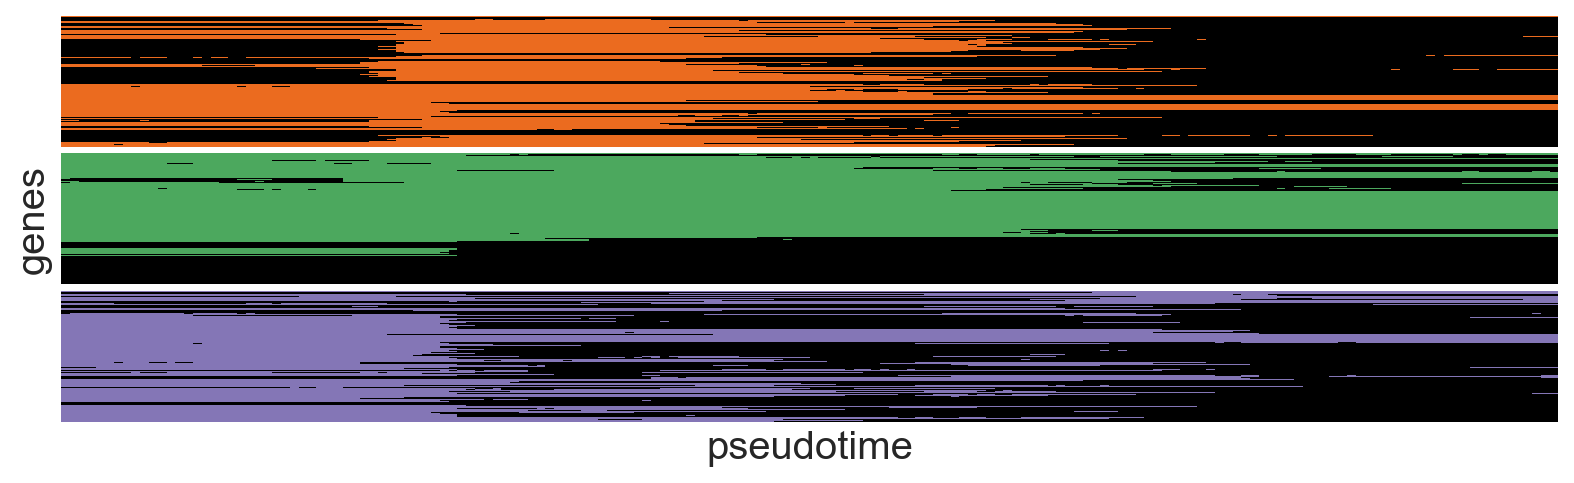

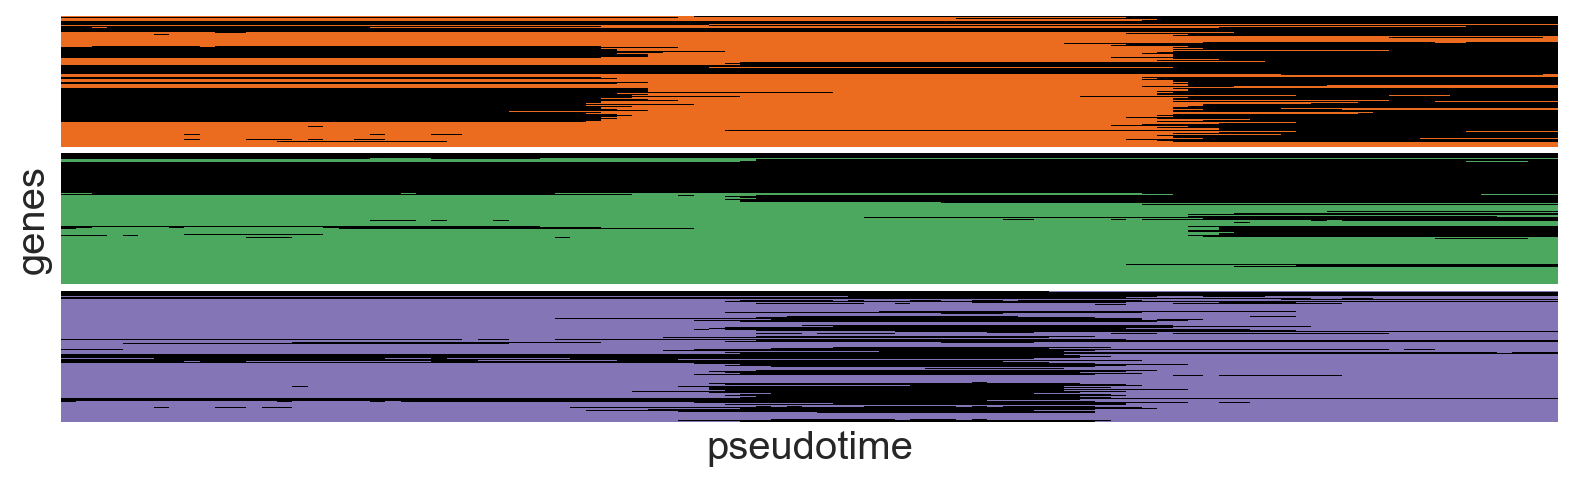

In [74]:
ar = 0.02
vals = 'sm_short_state_dyn'
v1 = 2
v2 = 2
v3 = 2
x = 'step'

plotheatmap_only(to_plot1, lineage = 'endo1', genelist = to_plot1.index.unique(), val = vals, xval = x,vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_endogenes_endo1_RT.png')
plotheatmap_only(to_plot2, lineage = 'mes1', genelist = to_plot2.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_mesogenes_mes1_RT.png')
plotheatmap_only(to_plot2, lineage = 'mes2', genelist = to_plot2.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_mesogenes_mes2_RT.png')
plotheatmap_only(to_plot2, lineage = 'mes3', genelist = to_plot2.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_mesogenes_mes3_RT.png')
plotheatmap_only(to_plot3, lineage = 'ect1', genelist = to_plot3.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_ectogenes_ect1_RT.png')
plotheatmap_only(to_plot3, lineage = 'ect2', genelist = to_plot3.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_ectogenes_ect2_RT.png')
plotheatmap_only(to_plot3, lineage = 'ect3', genelist = to_plot3.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_ectogenes_ect3_RT.png')

plotheatmap_only(to_plot4, lineage = 'mes1', genelist = to_plot4.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_plurigenes_mes1_RT.png')
plotheatmap_only(to_plot4, lineage = 'mes2', genelist = to_plot4.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_plurigenes_mes2_RT.png')
plotheatmap_only(to_plot4, lineage = 'mes3', genelist = to_plot4.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_plurigenes_mes3_RT.png')
plotheatmap_only(to_plot4, lineage = 'ect1', genelist = to_plot4.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_plurigenes_ect1_RT.png')
plotheatmap_only(to_plot4, lineage = 'ect2', genelist = to_plot4.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_plurigenes_ect2_RT.png')
plotheatmap_only(to_plot4, lineage = 'ect3', genelist = to_plot4.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_plurigenes_ect3_RT.png')
plotheatmap_only(to_plot4, lineage = 'endo1', genelist = to_plot4.index.unique(), val = vals, xval = x,  vmax_rna = v1, vmax_k4 = v2, vmax_k27 = v3,
                 aspect_ratio = ar,save = 'figs/20250305_heatmap_plurigenes_endo1_RT.png')

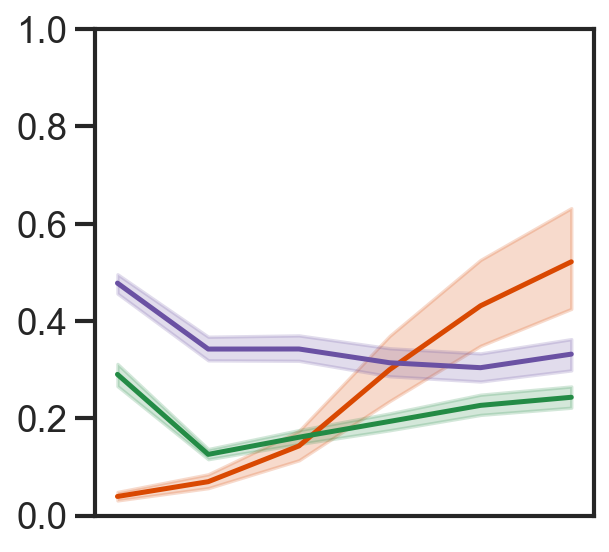

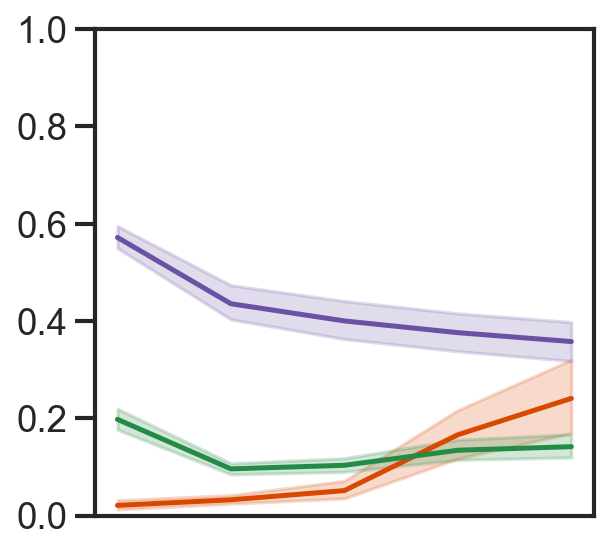

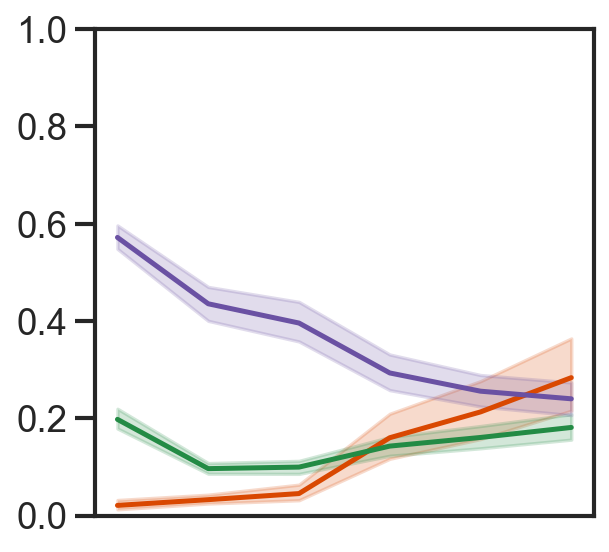

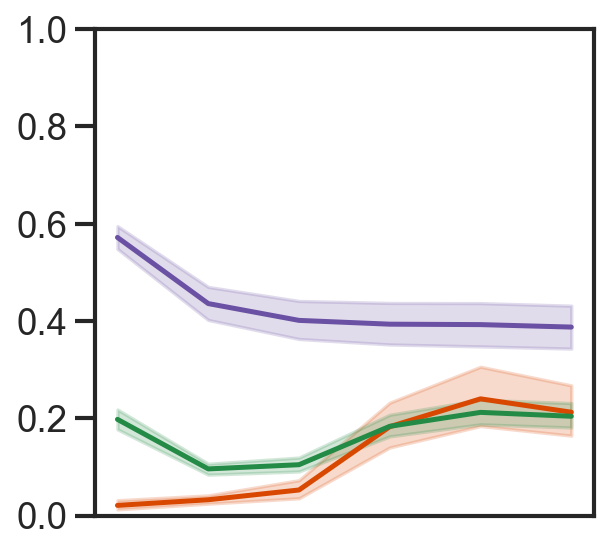

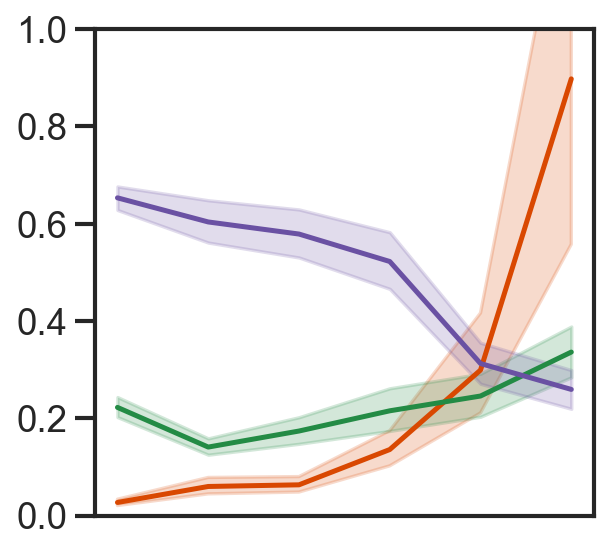

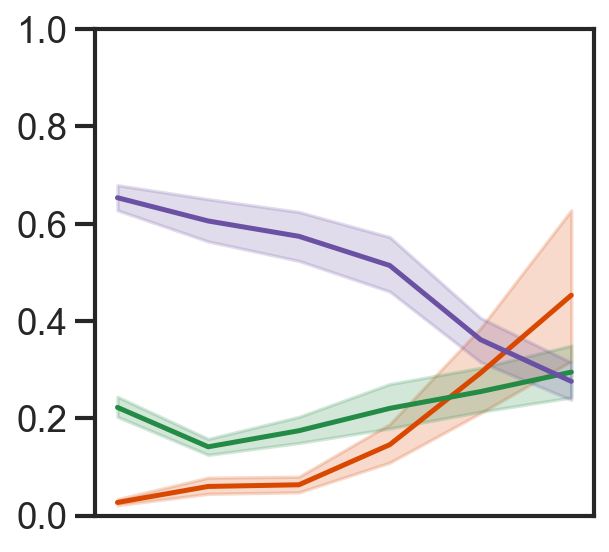

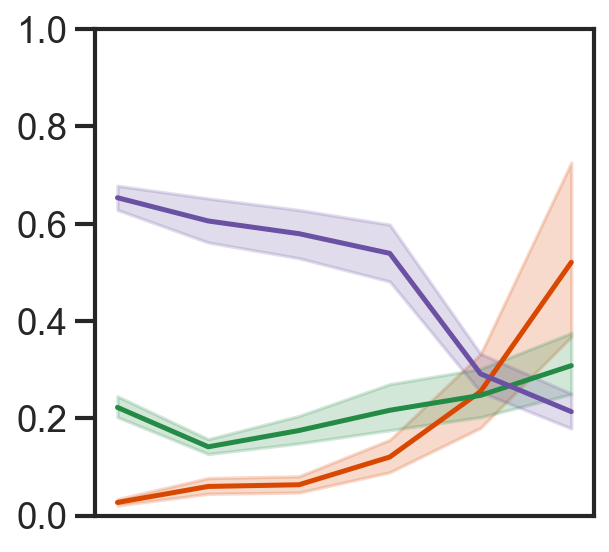

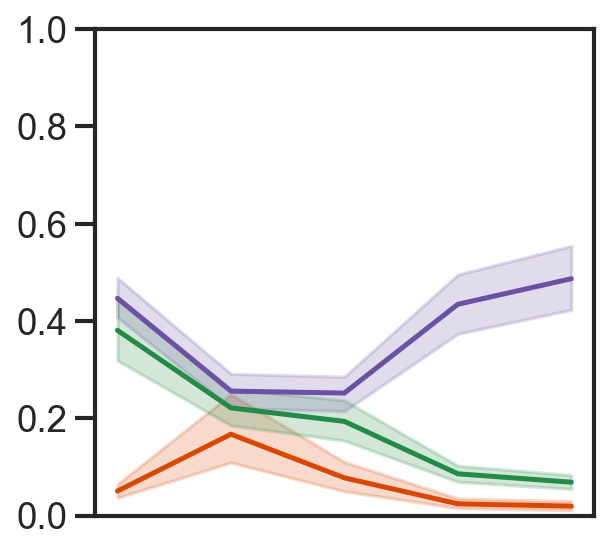

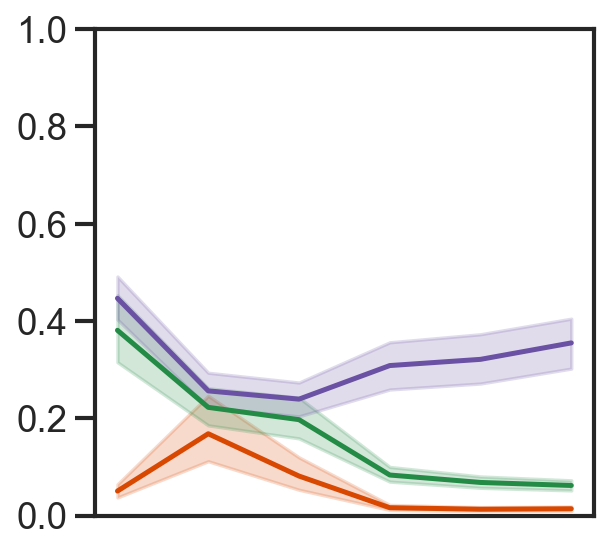

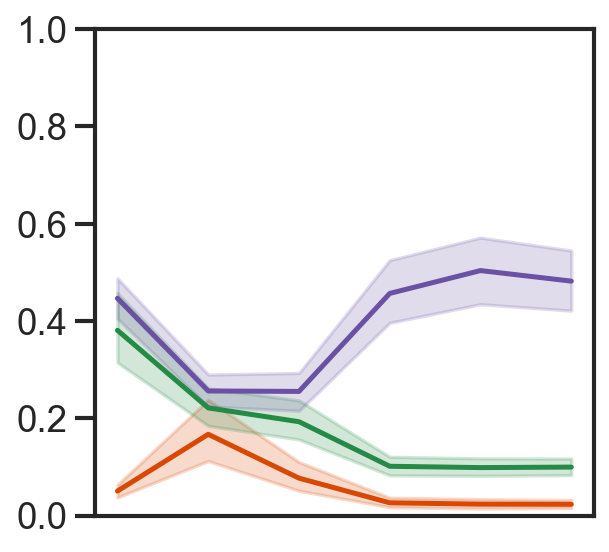

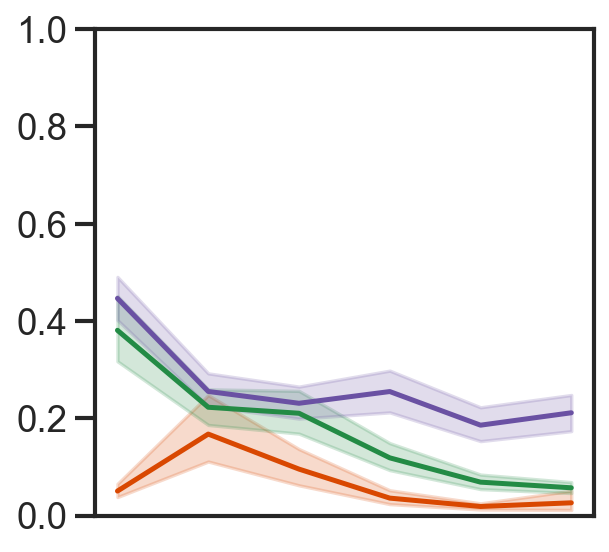

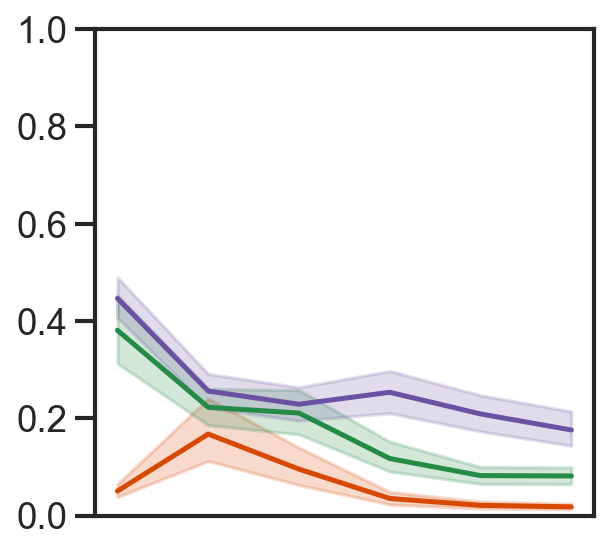

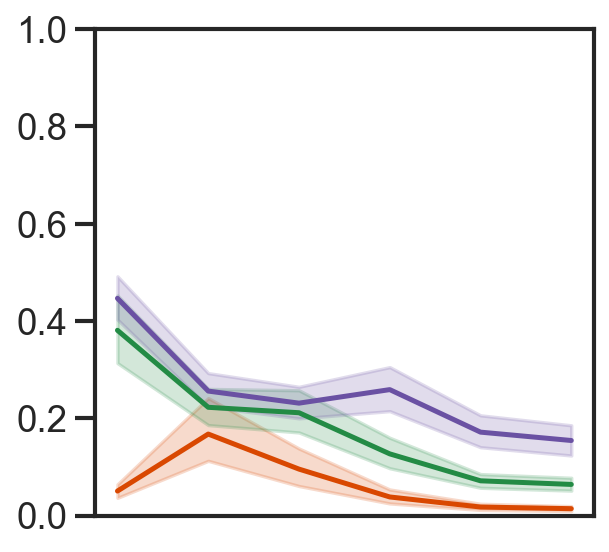

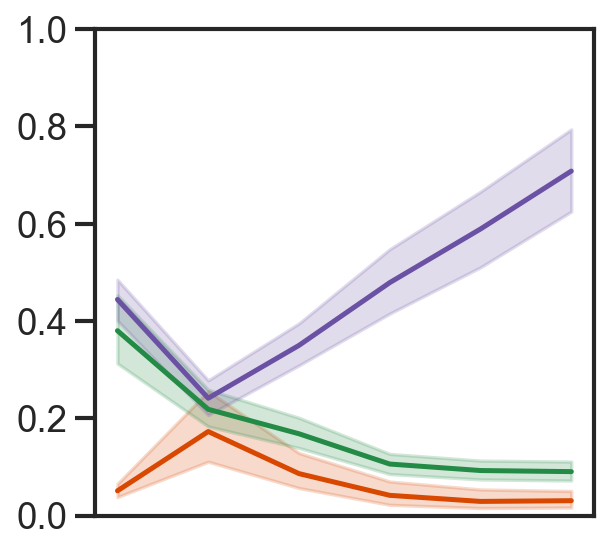

In [75]:
plotline(to_plot1, lineage = 'endo1', genelist = to_plot1.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_endogenes_endo1_RT.png')
plotline(to_plot2, lineage = 'mes1', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_mesogenes_mes1_RT.png')
plotline(to_plot2, lineage = 'mes2', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_mesogenes_mes2_RT.png')
plotline(to_plot2, lineage = 'mes3', genelist = to_plot2.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_mesogenes_mes3_RT.png')
plotline(to_plot3, lineage = 'ect1', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_ectogenes_ect1_RT.png')
plotline(to_plot3, lineage = 'ect2', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_ectogenes_ect2_RT.png')
plotline(to_plot3, lineage = 'ect3', genelist = to_plot3.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_ectogenes_ect3_RT.png')

plotline(to_plot4, lineage = 'mes1', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_mes1_RT.png')
plotline(to_plot4, lineage = 'mes2', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_mes2_RT.png')
plotline(to_plot4, lineage = 'mes3', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_mes3_RT.png')
plotline(to_plot4, lineage = 'ect1', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_ect1_RT.png')
plotline(to_plot4, lineage = 'ect2', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_ect2_RT.png')
plotline(to_plot4, lineage = 'ect3', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_ect3_RT.png')
plotline(to_plot4, lineage = 'endo1', genelist = to_plot4.index.unique(), val = 'p_98', xval = 'RT', save = 'figs/20250305_plurigenes_endo1_RT.png')

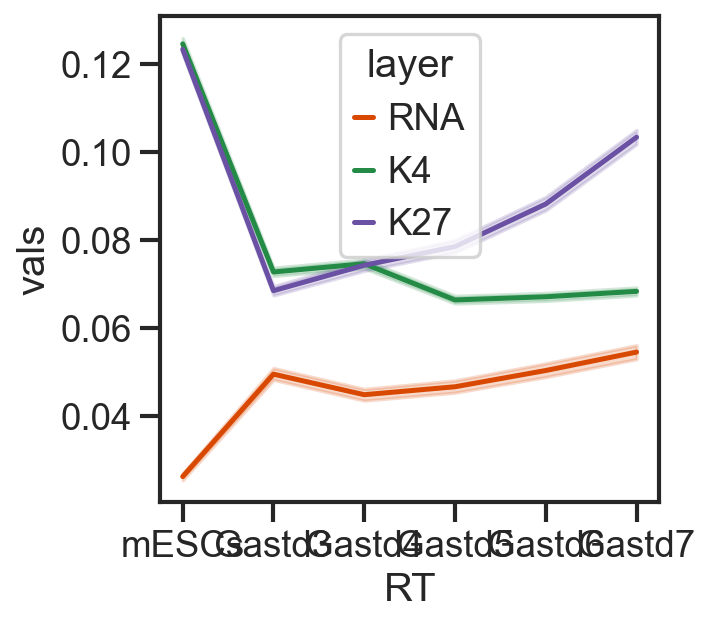

In [76]:
lineage = 'endo1'
val = 'p98_log10'
xval = 'RT'

df = pd.pivot_table(ct_normalised[ct_normalised['lin'] == lineage][[val, 'layer',xval]], columns = 'gene', index = ['layer',xval],values = val)
df_to_plot = pd.DataFrame(df.unstack().unstack()).rename(columns={0:'vals'})

sns.lineplot(data = df_to_plot,
                x = xval,
                y = 'vals',
                hue = 'layer',
                 hue_order = ['RNA','K4','K27'],
                palette = [Orange, Green, Purple])

plt.show()

# identify state changes

In [77]:
test1 = to_plot1[(to_plot1['lin'] == 'endo1')][['step','sm_short_state_fix','layer']]

In [78]:
test2 = to_plot1[['step','sm_short_state_fix','layer','lin']]

In [79]:
test2

,step,sm_short_state_fix,layer,lin
gene,,,,
Atp8a2,1,1.0,RNA,ect1
Atp8a2,2,1.0,RNA,ect1
Atp8a2,3,1.0,RNA,ect1
Atp8a2,4,1.0,RNA,ect1
Atp8a2,5,1.0,RNA,ect1
...,...,...,...,...
Cyp26a1,93,1.0,K27,endo1
Cyp26a1,94,1.0,K27,endo1
Cyp26a1,95,1.0,K27,endo1


In [80]:
def findStateChanges(df, state = 'sm_short_state_dyn'):
    df = df.reset_index().set_index(['step','gene','layer','lin'])
    df2 = df.copy()
    idx =df2.reset_index()['step']+1
    df2 = df2.reset_index().set_index([idx,'gene','layer','lin'])
    df['change'] = df[state] - df2[state]
    return df[df['change'] != 0].dropna().reset_index()

    

In [81]:
genes = list(test1.index.unique()[0:20])

In [82]:
changes = findStateChanges(test2,state = 'sm_short_state_fix')
changes

,step,gene,layer,lin,sm_short_state_fix,change
0,49,Bend5,K27,ect1,0.0,-1.0
1,49,Bend5,K27,ect2,0.0,-1.0
2,49,Bend5,K27,ect3,0.0,-1.0
3,49,Bend5,K27,mes1,0.0,-1.0
4,49,Bend5,K27,mes2,0.0,-1.0
...,...,...,...,...,...,...
17802,105,Cyp26a1,RNA,mes3,0.0,-1.0
17803,113,Cyp26a1,RNA,mes3,1.0,1.0
17804,67,Cyp26a1,RNA,endo1,1.0,1.0
17805,146,Cyp26a1,K4,ect3,0.0,-1.0


In [83]:
changes['change'].value_counts()

change
-1.0    9812
 1.0    7995
Name: count, dtype: int64

In [84]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [85]:
changes

,step,gene,layer,lin,sm_short_state_fix,change
0,49,Bend5,K27,ect1,0.0,-1.0
1,49,Bend5,K27,ect2,0.0,-1.0
2,49,Bend5,K27,ect3,0.0,-1.0
3,49,Bend5,K27,mes1,0.0,-1.0
4,49,Bend5,K27,mes2,0.0,-1.0
...,...,...,...,...,...,...
17802,105,Cyp26a1,RNA,mes3,0.0,-1.0
17803,113,Cyp26a1,RNA,mes3,1.0,1.0
17804,67,Cyp26a1,RNA,endo1,1.0,1.0
17805,146,Cyp26a1,K4,ect3,0.0,-1.0


In [86]:
changes['step']

0         49
1         49
2         49
3         49
4         49
        ... 
17802    105
17803    113
17804     67
17805    146
17806    160
Name: step, Length: 17807, dtype: int64

In [87]:
 plt.set_loglevel('WARNING') 

ect1


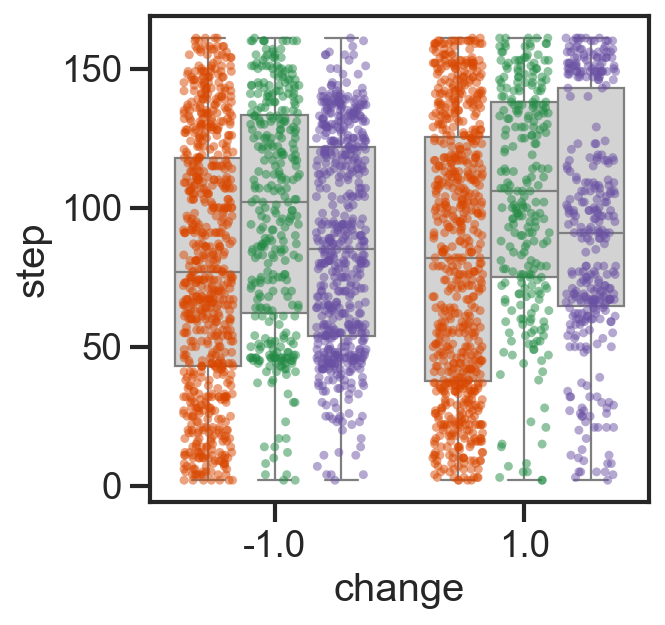

ect2


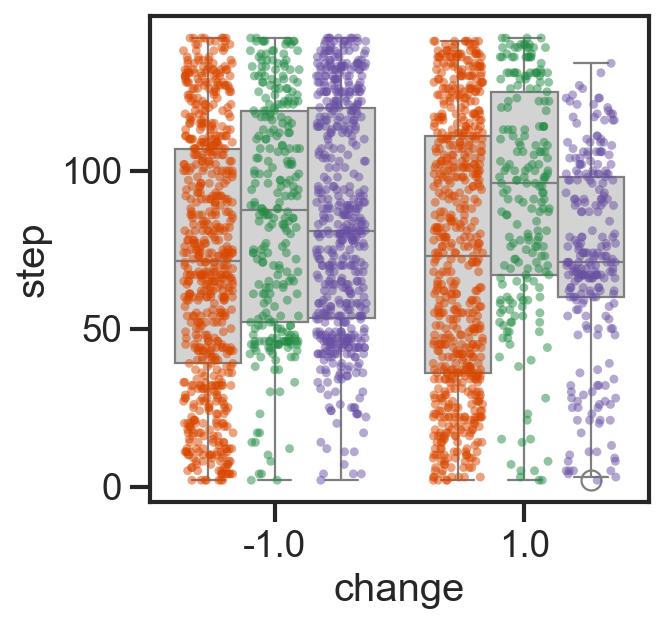

ect3


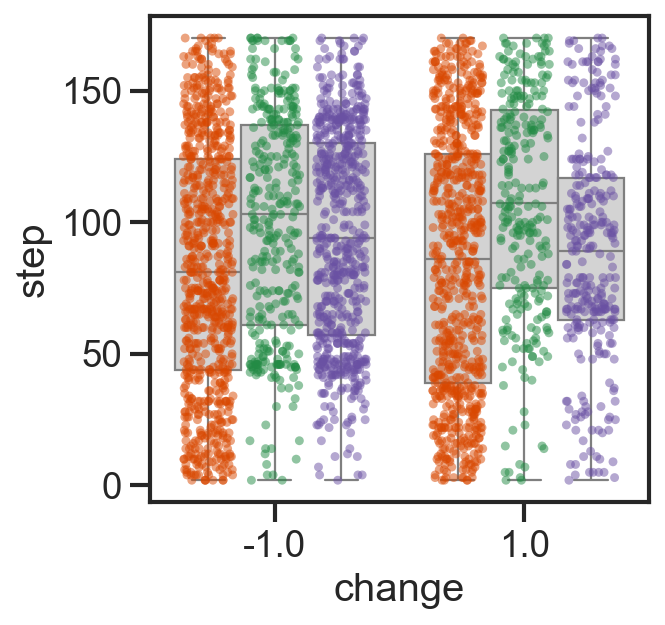

mes1


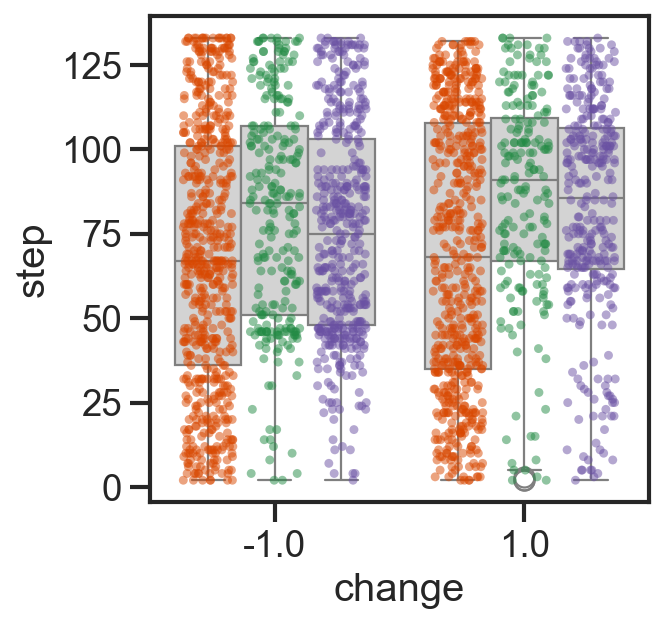

mes2


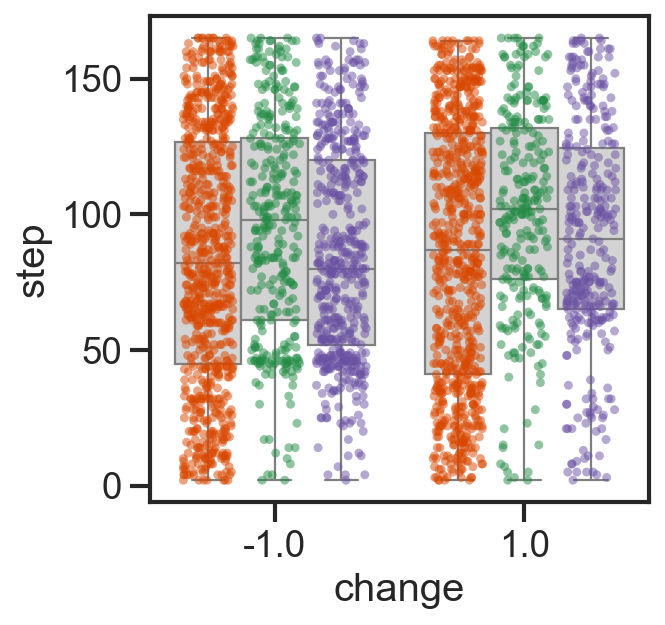

mes3


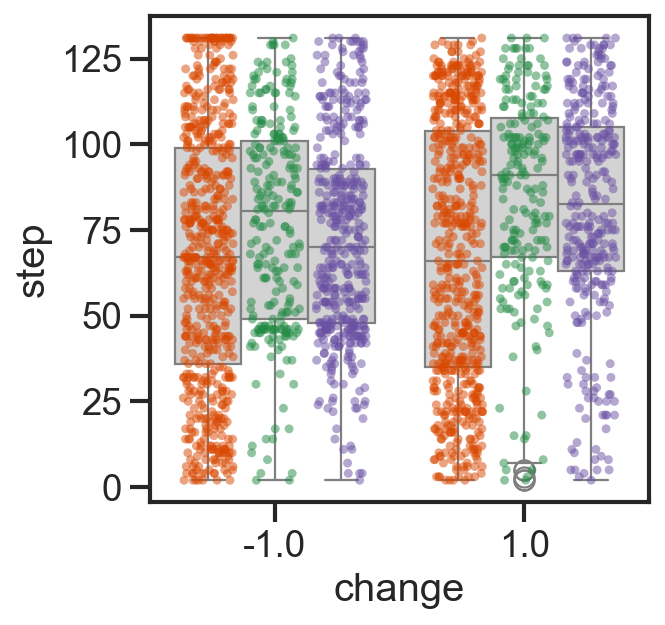

endo1


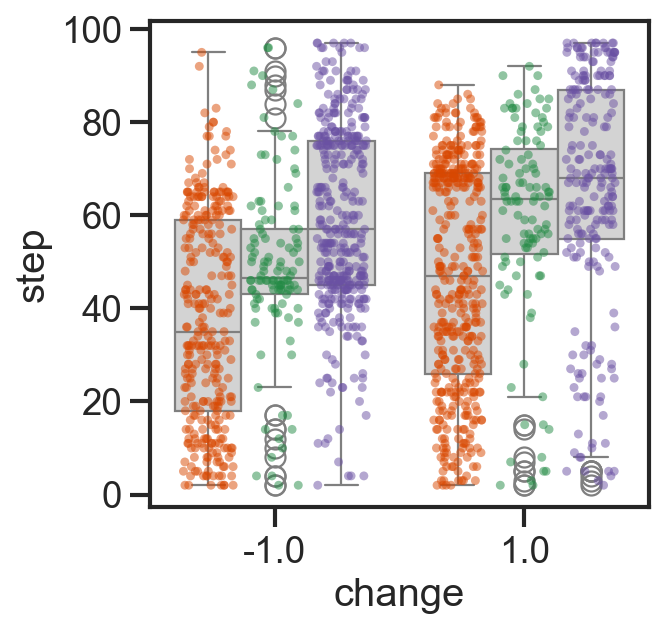

In [88]:
for lins in changes['lin'].unique():
    print(lins)
    
    sns.stripplot(data = changes[changes['lin'] == lins],
                    y = 'step', palette =[Orange,Green,Purple], hue_order = ['RNA','K4','K27']
                  ,s = 4, alpha = 0.5,# [lightOrange,Orange,lightPurple,Purple,lightGreen,Green], 
                  jitter = 0.3,
                    x = 'change',
                  hue = 'layer',dodge = True)
    sns.boxplot(data = changes[changes['lin'] == lins],
                   y = 'step',palette = ['lightgrey','lightgrey','lightgrey'],
                x = 'change',hue_order = ['RNA','K4','K27'],
                    hue = 'layer', dodge = True)
    plt.legend([],frameon = False)
    plt.show()

In [89]:
t1[t1['change'] != 0]

NameError: name 't1' is not defined

In [ ]:
to_plot1.head(2)

In [ ]:
tests = to_plot1[(to_plot1['lin'] == 'endo1') & (to_plot1['layer'] == 'RNA')][['step','sm_short_state_fix','sm_short_state_dyn']]#.loc['Car2']

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (8,4))
sns.scatterplot(data = tests.loc['Car2'],ax=ax[0],
                x = 'step',
                y = 'sm_short_state_fix')
sns.scatterplot(data = tests.loc['Car2'],ax=ax[1],
                x = 'step',
                y = 'sm_short_state_dyn')
plt.show()

In [ ]:
changes[changes['gene']=='Car2']